# Introduction

Fundamentally, calibration is an *optimization* problem, in the sense that we are given some data, have a model of the data, and want to find the model parameters that best fit the data. To that end, I would like you to work through some progressively more challenging optimization problems to build up to gaining a rough understanding of how CorrCal works. For this notebook, you will only need `numpy`, `matplotlib`, and `scipy` installed.

Before jumping into any of the details, I want to take some time to more clearly define what I mean when I discuss optimization problems. The simple setup is that I have some data $\{d_i\}$, I have some parametric model of the data $m(\vec{\theta})$, and I want to find the set of parameters $\{\theta_j\}$ that gives me the "best fit" to the data. (A bit more generally, the model doesn't even need to be parametric, but we won't get into that here.) Mathematically, I can define some notion of distance between the model and the data, and I can find the best-fit parameters by minimizing the "distance" between the model and the data. So, the optimization problem we're concerned with here is as follows:  
  
**Given some objective function $f(\vec{\theta},\vec{d})$, what is the set of parameters $\{\hat{\theta}_j\}$ that minimizes $f$?**  
  
I like to think that there are different "classes" of optimization problems that are characterized by the choice of objective function, and these classes are split into "subclasses" based on the techniques employed to find the solution.

## Imports

In [10]:
import numpy as np

import matplotlib.pyplot as plt
from scipy.optimize import minimize
%matplotlib inline

# Least-Squares

In the language introduced above, the method of least-squares would qualify as one class of optimization problems. The objective function used in least-squares approach is the (hopefully familiar) $\chi^2$:  
  
$$
    \chi^2 = \sum_i \frac{|d_i - m_i(\vec{\theta})|^2}{\sigma_i^2}.
$$
  
In words, $\chi^2$ is the inverse-variance weighted average of the distance between the data and the model (under the $L^2$, or Euclidean, norm). The variance $\sigma_i^2$ is just a measure of how noisy the data is, with noisier data having higher variance. Inverse-variance weighting is therefore a way to encode the idea that we should have more trust in data that is less noisy. There is a natural way of coming to use $\chi^2$ as the objective function, which we will come back to in the Maximum Likelihood section, but for now you can think of $\chi^2$ as a measure of the average distance between the model and the data.  
  
There are basically two flavors of least-squares problems, and which flavor you need to employ depends on the nature of the model, which we'll explore further in the following section. (The Wikipedia page reveals that there is more complexity than this, but I've never needed to know more than a slightly more generalized form of what is covered below.)

## Linear Least-Squares

*Linear* least-squares refers to the class of problems where the model $\vec{m}$ is a linear transformation of the model parameters $\vec{\theta}$, in the sense that we may write  
  
$$
    \vec{m} = {\bf A} \vec{\theta},
$$
  
where the *design matrix* ${\bf A}$ encodes that linear transformation. Making this substitution, $\chi^2$ can be written as a simple matrix equation:  
  
$$
    \chi^2 = (\vec{d} - {\bf A}\vec{\theta})^T {\bf N}^{-1} (\vec{d} - {\bf A}\vec{\theta}),
$$
  
where the noise matrix ${\bf N}$ is a diagonal matrix whose entries are the variance in the data $N_{ij} = \sigma_i^2 \delta_{ij}$. Remember that the goal is to find the choice of model parameters $\vec{\theta}$ that produces the closest match to the observed data $\vec{d}$, which we can do by minimizing $\chi^2$. Since $\chi^2$ is non-negative and a quadratic function of the model parameters, we can find the best-fit parameters $\hat{\theta}$ that minimize $\chi^2$ by determining where the gradient of $\chi^2$ vanishes. That is, the optimal solution is the one satisfying  
  
$$
    \frac{\partial \chi^2}{\partial \vec{\theta}} = 0.
$$
  
Skipping over some of the math, this gives us the condition  
  
$$
    {\bf A}^T {\bf N}^{-1} \vec{d} - {\bf A}^T {\bf N}^{-1} {\bf A} \vec{\theta} = 0,
$$
  
which we can invert to obtain the best-fit parameters  
  
$$
    \hat{\theta} = ({\bf A}^T {\bf N}^{-1} {\bf A})^{-1} {\bf A}^T {\bf N}^{-1} \vec{d}.
$$
  
Solving linear least-squares problems thus boils down to a problem of constructing the design matrix and estimating the noise in the data. Let's work through a few examples.

### Fitting a Polynomial

For this first example, we will generate some noisy data that follows a polynomial, then perform a linear least-squares fit to determine the coefficients of the polynomial and check against the true values used in simulation to validate our solution. This last step is not a luxury we have when working with real data, but it is an important step to perform when proposing a method of fitting the data (in other words, it is a very good idea to *validate* that your proposed optimization routine works).  
  
To make the math a bit clearer, our data will be constructed via  
  
$$
    y_i = \sum_m a_m x_i^m + n_i,
$$
  
where $\{a_m\}$ are the model parameters and $n_i$ is the noise in measurement $i$. We will use mean-zero Gaussian random noise with a fixed variance, which is mathematically encoded in the expression  
  
$$
    n_i \sim \mathcal{N}(0,\sigma^2).
$$

In [11]:
# Define the polynomial coefficients.
poly_coeffs = np.array([1, -3, 0, 5, -2])

# Come up with a range of x-values for which we will simulate data.
x_values = np.linspace(-1, 1, 1001)
# Now generate the simulated data. There is a more clever way to do this,
# but I think this way is a bit easier to understand.
y_values = np.zeros_like(x_values)
for m, a_m in enumerate(poly_coeffs):
    y_values += a_m * x_values**m
    
# Now add noise.
var = 0.1
y_values += np.random.normal(size=y_values.size, loc=0, scale=np.sqrt(var))

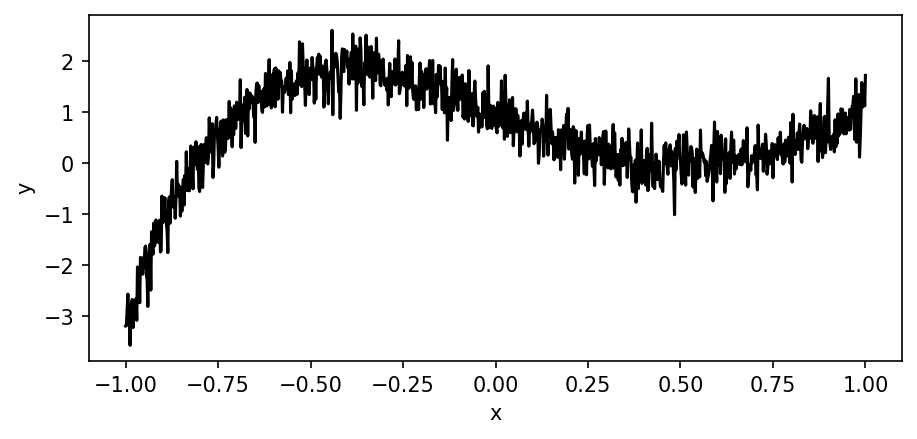

In [12]:
# Let's take a quick look at the simulated data to see if it looks reasonable.
plt.figure(figsize=(7,3), dpi=150)
plt.plot(x_values, y_values, color="k")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

This quick check confirms that the simulated data does indeed look like a polynomial with some additive noise.

In [13]:
# First step, we need to define the design matrix.
# Thinking about shapes (how are matrix products defined?): 
# There must be as many columns as there are model parameters.
# There must be as many rows as there are data points.
A = np.zeros((x_values.size, poly_coeffs.size), dtype=float)
for m in range(poly_coeffs.size):
    A[:,m] = x_values ** m
# Construct the inverse noise matrix, but we only need the diagonal.
N_inv = np.ones(x_values.size) / var

# Now we can figure out the best-fit values in one line!
fit_coeffs = np.linalg.inv(
    A.T @ (N_inv[:,np.newaxis] * A)
) @ A.T @ (N_inv * y_values)

In [14]:
# Let's see if the fit values match what we put in!
print(f"Input parameters: {poly_coeffs}")
print(f"Best-fit parameters: {fit_coeffs}")

Input parameters: [ 1 -3  0  5 -2]
Best-fit parameters: [ 0.96731535 -3.0682657   0.11435611  5.12009703 -2.07467176]


That looks pretty close to me! Let's evaluate the model and compare it to the input data.

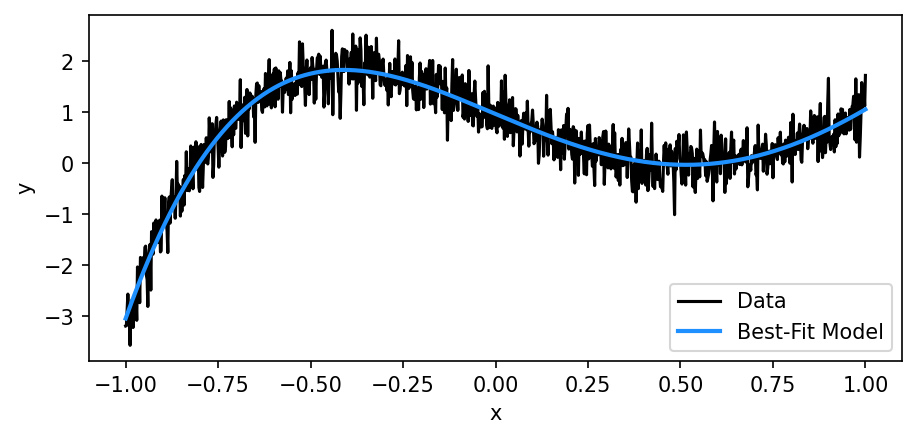

In [15]:
# In case you are unfamiliar with the @ operator, "@" used here stands for "mATrix multiply"
model = A @ fit_coeffs
plt.figure(figsize=(7,3), dpi=150)
plt.plot(x_values, y_values, color="k", label="Data")
plt.plot(x_values, model, color="dodgerblue", lw=2, label="Best-Fit Model")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

This looks like a pretty good fit to me! We can make a more quantitative estimate of how good the fit is by computing $\chi^2$ *per degree of freedom*, or $\chi^2/{\rm DoF}$. Unfortunately, "degree of freedom" is used in kind of a backwards way when people are talking about model fitting compared to how it is used in computing $\chi^2/{\rm DoF}$&mdash;colloquially, when someone is talking about "adding degrees of freedom" (or "opening up degrees of freedom") to (in) a model, they mean adding extra model parameters, but when computing $\chi^2/{\rm DoF}$, the "degrees of freedom" is actually the number of extra data points you have beyond the number of model parameters. A good rule-of-thumb (which comes from figuring out, on average, what should I obtain for $\chi^2/{\rm DoF}$ if my fit is good?) is that a good fit and properly estimated errors will have $\chi^2/{\rm DoF} \approx 1$. You may have already been introduced to this quantity as "reduced $\chi^2$" in some of your physics labs.

In [16]:
chisq = (y_values - model) @ (N_inv * (y_values - model))
dof = y_values.size - poly_coeffs.size
chisq_per_dof = chisq / dof
print(chisq_per_dof)

0.9915184517192608


Something that was likely not taught in your physics labs, however, is how close $\chi^2/{\rm DoF}$ should be to $1$ for the fit to be considered "good". One way to think about this is to treat $\chi^2$ as a random variable that follows some probability distribution. Perhaps unsurprisingly, $\chi^2$ follows a [chi-squared distribution](https://en.wikipedia.org/wiki/Chi-squared_distribution), which is uniquely characterized by the degrees of freedom. A chi-squared distribution with ${\rm DoF}$ degrees of freedom has mean ${\rm DoF}$ and variance $2{\rm DoF}$, which means $\chi^2/{\rm DoF}$ has mean $1$ and variance $2/{\rm DoF}$. More degrees of freedom therefore corresponds to a tighter distribution of $\chi^2/{\rm DoF}$ values centered on $1$. Intuitively, the more data we use to optimize our fit (i.e., the more degrees of freedom in the statistical sense), the closer we ought to expect $\chi^2/{\rm DoF}$ to be $1$ to consider our fit as "good". With this framework in mind, we can ask how many standard deviations away from $1$ our measured $\chi^2/{\rm DoF}$ is, and if this number is high, then our fit is probably not good.

In [17]:
chisq_per_dof_stdev = np.sqrt(2 / dof)
(1 - chisq_per_dof) / chisq_per_dof_stdev

np.float64(0.18927349866470516)

As a rule of thumb, if our fit has $\chi^2/{\rm DoF}$ within one or two standard deviations of $1$, then it is likely that our model is a good description of the data and we have correctly estimated the noise level in the data. Otherwise, it may be time to re-evaluate either the model or our approach for estimating the noise in the data.

### Fitting a Power Law

In astronomy, we often need to work with power laws, so it's useful to learn how to fit them. A power law is something that looks like the following:  
  
$$
    S(\nu) = S_0 (\nu/\nu_0)^{-\beta}.
$$
  
In this case, $S_0$ is the flux that is observed at frequency $\nu_0$, and $\beta$ is called the *spectral index*.

**Question:**  
* Take the logarithm of the above quation to linearize the problem. How are the linearized parameters related to the reference flux $S_0$, the reference frequency $\nu_0$, and the spectral index $\beta$?

Let's cook up some data and try to fit a power law to it.

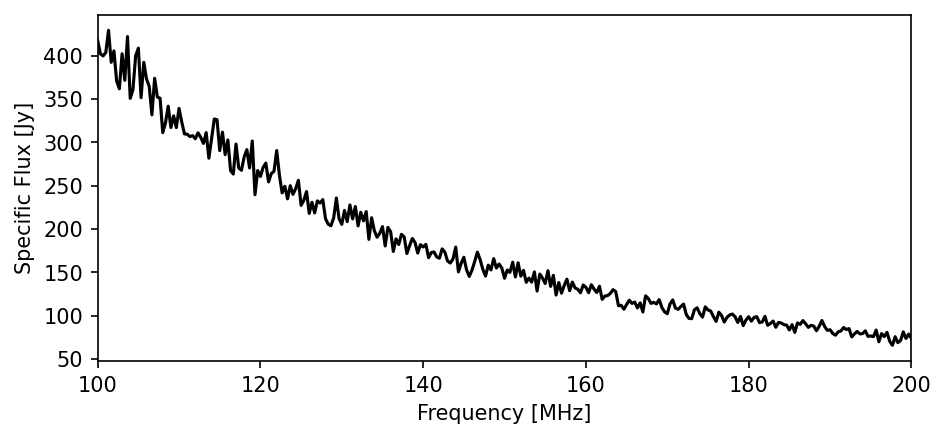

In [104]:
# First, simulate the "true" data.
spectral_index = 2.5
ref_flux_Jy = 150
ref_freq_MHz = 150
obs_freqs_MHz = np.linspace(100, 200, 301)
true_data = ref_flux_Jy * (obs_freqs_MHz/ref_freq_MHz) ** -spectral_index
# Now add some noise that scales with the brightness of the signal.
noisy_data = true_data * (
    1 + np.random.normal(size=true_data.size, loc=0, scale=0.05)
)

# Then take a look at the data.
fig, ax = plt.subplots(1, 1, figsize=(7,3), dpi=150)
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("Specific Flux [Jy]")
ax.plot(obs_freqs_MHz, noisy_data, color="k")
ax.set_xlim(obs_freqs_MHz[0], obs_freqs_MHz[-1])
fig.savefig("power_law_noisy_data.pdf", format="pdf", bbox_inches="tight")
plt.show()

Does this look right? Try making a log-log plot and see if that looks the way you expect based on your answer to the question at the beginning of this section.

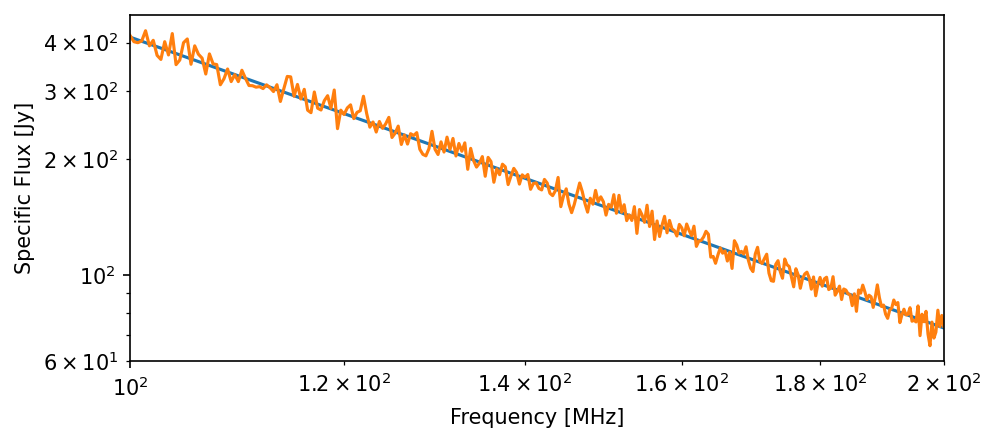

In [105]:
# Write your plotting code here.
"""Does this look right? 
Try making a log-log plot and see if that looks the way you expect based on your answer to the question at the beginning of this section.
After plotting the log-log plot, the result is what we are expected after linearizing the power law into y=a+bx format where y= log() a =, b=-beta"""
fig, ax = plt.subplots(1, 1, figsize=(7,3), dpi=150)
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("Specific Flux [Jy]")
plt.loglog(obs_freqs_MHz, true_data)
plt.loglog(obs_freqs_MHz, noisy_data)
ax.set_xlim(obs_freqs_MHz[0], obs_freqs_MHz[-1])
plt.savefig("power_law_loglog.pdf", format="pdf", bbox_inches="tight")
plt.show()

Now let's suppose we only know the observed frequencies and the measured data, then try to fit a power law to it. I'll outline the steps, but you'll need to fill in the code. For this problem, we'll ignore the inverse-variance weighting (i.e., we will use *uniform* weighting).  
  
**Questions:**  
* If we're not inverse variance weighting, what is the correct expression for the noise matrix ${\bf N}$?
* What is the expression for the best-fit parameters in the case of uniform weighting?
* How many rows and columns should the design matrix ${\bf A}$ have for this problem? What should the terms in the design matrix be?

In [ ]:
"""
Quesiton:
If we're not inverse variance weighting, what is the correct expression for the noise matrix ? 
Uniform weighting is when wi = 1 (for X^2 N^-1 is 1/varinace^2), thus for uniform weighting, the noise matrix is N_inv= I (identity matrix)
What is the expression for the best-fit parameters in the case of uniform weighting? theta = np.linalg.inv(A.T@A)@A.T@d since N_inv is an identity matrix
How many rows and columns should the design matrix A have for this problem? What should the terms in the design matrix be? 
the column of the A matrix should be len(obs_frequency), the row should be
"""

In [106]:
# Define the design matrix.
# Linearize the variables
x = np.log(obs_freqs_MHz)
y = np.log(noisy_data)
# Build design matrix
A = np.zeros((x.size, 2))
A[:,0] = 1
A[:,1] = x
print(len(A))
# Compute the best-fit parameters.
best_fit = np.linalg.inv(A.T @ A) @ A.T @ y
print("best_fit size",best_fit.size)
a = best_fit[0]
b = best_fit[1]
print(best_fit)
# Convert these to the spectral index and the flux at 150 MHz.
fit_spectral_index = -b #beta
fit_ref_flux = np.exp(a - fit_spectral_index * np.log(ref_freq_MHz)) #So
# Compare the result against the true values.
print("True spectral index:", spectral_index)
print("Fitted spectral index:", fit_spectral_index)
print("True reference flux:", ref_flux_Jy)
print("Fitted reference flux:", fit_ref_flux)

301
best_fit size 2
[17.57755394 -2.50713601]
True spectral index: 2.5
Fitted spectral index: 2.5071360087753076
True reference flux: 150
Fitted reference flux: 150.68774217629485


How do your best-fit values compare against the true values? Try making a plot of the best-fit *model* against the data.

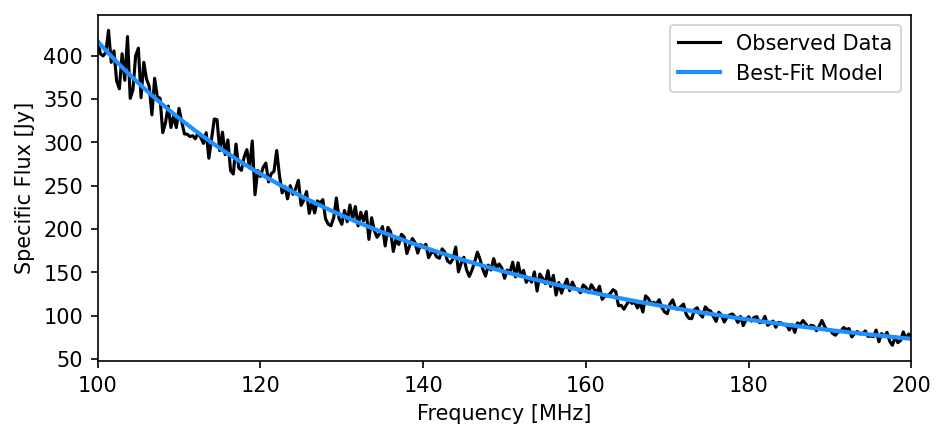

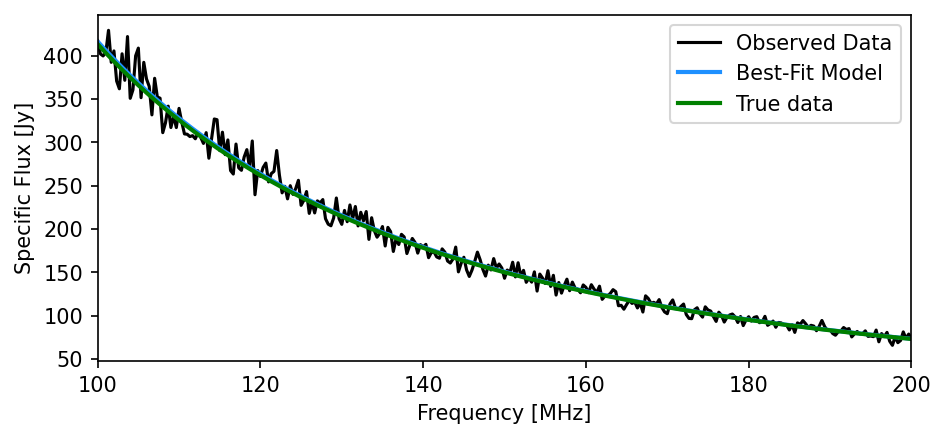

In [107]:
# Evaluate the best-fit model.
fit_model = fit_ref_flux * (obs_freqs_MHz / ref_freq_MHz) ** (-fit_spectral_index) #plug the best fit parameter back into the power law to estimate the outcome
# Plot the best-fit model and the data.
plt.figure(figsize=(7,3), dpi=150)
plt.plot(obs_freqs_MHz, noisy_data, color="k", label="Observed Data")
plt.plot(obs_freqs_MHz, fit_model, color="dodgerblue", lw=2, label="Best-Fit Model")
plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel("Specific Flux [Jy]")
plt.xlim(obs_freqs_MHz[0], obs_freqs_MHz[-1])
plt.savefig("power_law_fit_only.pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,3), dpi=150)
plt.plot(obs_freqs_MHz, noisy_data, color="k", label="Observed Data")
plt.plot(obs_freqs_MHz, fit_model, color="dodgerblue", lw=2, label="Best-Fit Model")
plt.plot(obs_freqs_MHz, true_data, color="g", lw=2, label="True data")
plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel("Specific Flux [Jy]")
plt.xlim(obs_freqs_MHz[0], obs_freqs_MHz[-1])
plt.savefig("power_law_fit_vs_true.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [108]:
#checking if the best fit model is valid
fit_model = fit_ref_flux * (obs_freqs_MHz / ref_freq_MHz) ** (-fit_spectral_index)
sigma = 0.05 * true_data   # <-- use SAME fractional noise used in simulation
residuals = noisy_data - fit_model
chisq = np.sum((residuals / sigma) ** 2)
dof = len(noisy_data) - best_fit.size
chisq_per_dof = chisq / dof
chisq_per_dof_stdev = np.sqrt(2 / dof)
z_score = (chisq_per_dof - 1) / chisq_per_dof_stdev
print("Chi-squared:", chisq)
print("DOF:", dof)
print("Reduced chi-squared:", chisq_per_dof)
print("Expected stdev:", chisq_per_dof_stdev)
print("Z-score:", z_score)

Chi-squared: 307.78495938835283
DOF: 299
Reduced chi-squared: 1.029381135078103
Expected stdev: 0.08178608201095307
Z-score: 0.35924370449935733


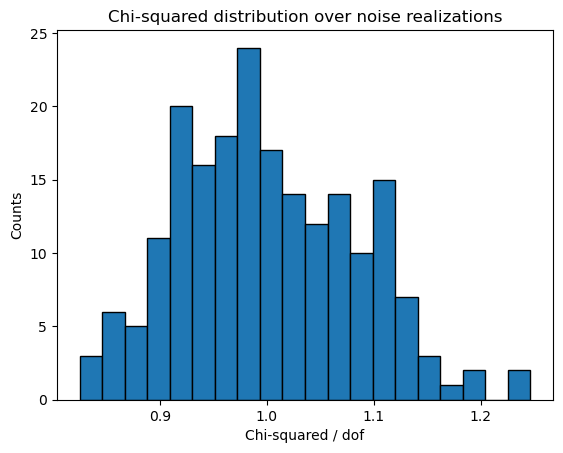

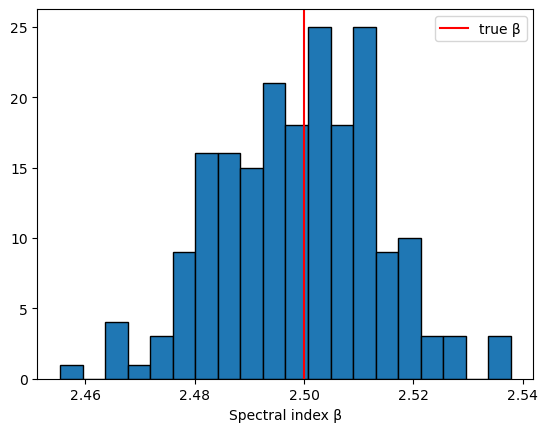

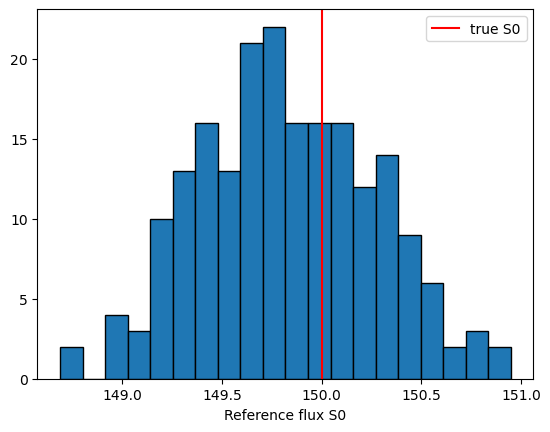

In [109]:
def fit_one_realization(obs_freqs_MHz, noisy_data, ref_freq_MHz):
    x = np.log(obs_freqs_MHz / ref_freq_MHz)
    y = np.log(noisy_data)

    A = np.zeros((x.size, 2))
    A[:, 0] = 1
    A[:, 1] = x

    best_fit = np.linalg.inv(A.T @ A) @ A.T @ y
    a = best_fit[0]
    b = best_fit[1]

    s0 = np.exp(a) 
    beta = -b

    return s0, beta
    
N = 200
beta_vals = []
s0_vals = []
chi2_vals = []
for i in range(N):
    # new noise each time
    noisy_data = true_data * (
        1 + np.random.normal(0, 0.05, size=true_data.size)
    )
    s0_fit, beta_fit = fit_one_realization(
        obs_freqs_MHz,
        noisy_data,
        ref_freq_MHz
    )
    beta_vals.append(beta_fit)
    s0_vals.append(s0_fit)
    # rebuild model for chi-squared
    model = s0_fit * (obs_freqs_MHz / ref_freq_MHz) ** (-beta_fit)
    sigma = 0.05 * true_data  # known noise level
    chi2 = np.sum(((noisy_data - model) / sigma) ** 2)
    dof = len(obs_freqs_MHz) - 2
    chi2_vals.append(chi2 / dof)

plt.hist(chi2_vals, bins=20, edgecolor='k')
plt.xlabel("Chi-squared / dof")
plt.ylabel("Counts")
plt.title("Chi-squared distribution over noise realizations")
plt.savefig("chi2_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

plt.hist(beta_vals, bins=20, edgecolor='k')
plt.axvline(spectral_index, color='r', label="true β")
plt.xlabel("Spectral index β")
plt.legend()
plt.savefig("beta_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

plt.hist(s0_vals, bins=20, edgecolor='k')
plt.axvline(ref_flux_Jy, color='r', label="true S0")
plt.xlabel("Reference flux S0")
plt.legend()
plt.savefig("s0_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

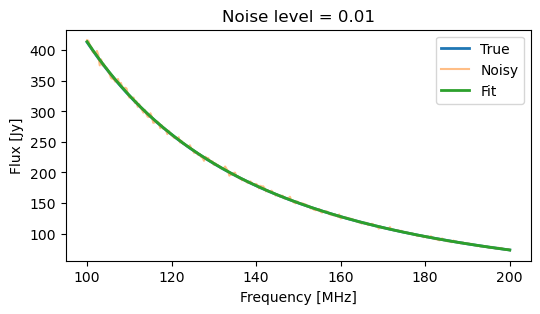

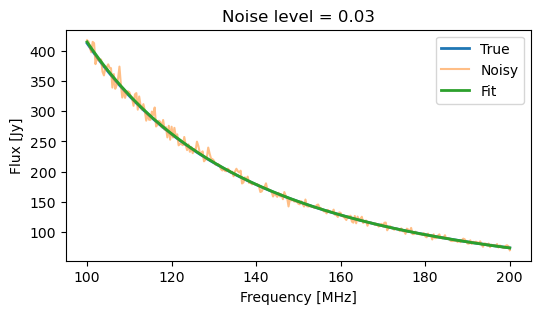

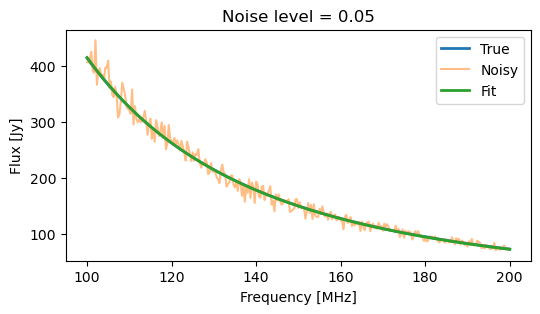

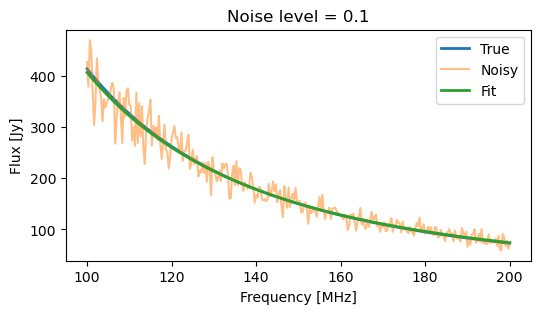

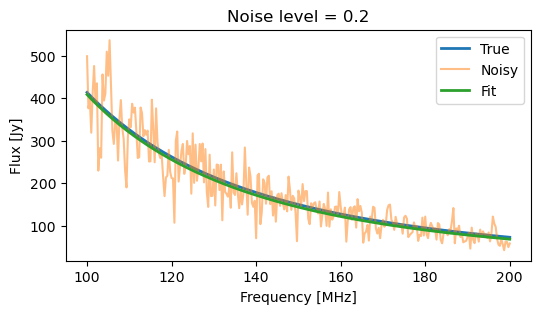

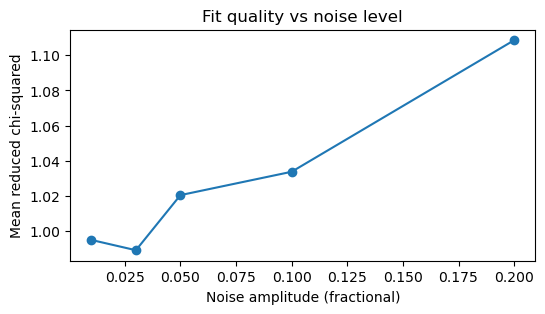

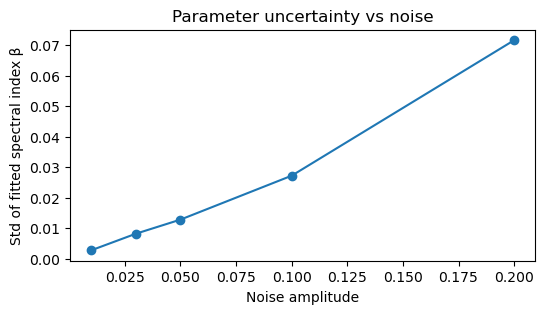

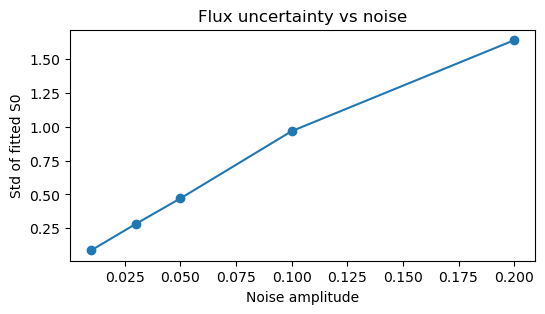

In [111]:
noise_levels = [0.01, 0.03, 0.05, 0.1, 0.2]
N_realizations = 50
chi2_mean = []
beta_std = []
s0_std = []
x = np.log(obs_freqs_MHz / ref_freq_MHz)
A = np.vstack([np.ones_like(x), x]).T

for sigma_frac in noise_levels:
    beta_vals = []
    s0_vals = []
    chi2_vals = []
    for i in range(N_realizations):
        noise = np.random.normal(0, sigma_frac, size=true_data.size)
        noisy = true_data * (1 + noise)
        y = np.log(noisy)
        a_fit, b_fit = np.linalg.lstsq(A, y, rcond=None)[0]
        beta_fit = -b_fit
        s0_fit = np.exp(a_fit)
        fit_model = s0_fit * (obs_freqs_MHz / ref_freq_MHz) ** (-beta_fit)
        y_data = np.log(noisy)
        y_model = np.log(fit_model)
        chi2 = np.sum(((y_data - y_model) / sigma_frac) ** 2)
        dof = len(obs_freqs_MHz) - 2
        chi2_vals.append(chi2 / dof)
        beta_vals.append(beta_fit)
        s0_vals.append(s0_fit)
    chi2_mean.append(np.mean(chi2_vals))
    beta_std.append(np.std(beta_vals))
    s0_std.append(np.std(s0_vals))
    noisy = np.random.normal(0, sigma_frac, size=true_data.size)
    noisy = true_data * (1 + noise)
    y = np.log(noisy)
    a_fit, b_fit = np.linalg.lstsq(A, y, rcond=None)[0]
    beta_fit = -b_fit
    s0_fit = np.exp(a_fit)
    fit_model = s0_fit * (obs_freqs_MHz / ref_freq_MHz) ** (-beta_fit)
    plt.figure(figsize=(6, 3))
    plt.plot(obs_freqs_MHz, true_data, label="True", linewidth=2)
    plt.plot(obs_freqs_MHz, noisy, label="Noisy", alpha=0.5)
    plt.plot(obs_freqs_MHz, fit_model, label="Fit", linewidth=2)
    plt.title(f"Noise level = {sigma_frac}")
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Flux [Jy]")
    plt.legend()
    plt.savefig(f"fit_example_noise_{sigma_frac}.pdf", bbox_inches="tight")
    plt.show()

plt.figure(figsize=(6, 3))
plt.plot(noise_levels, chi2_mean, marker='o')
plt.xlabel("Noise amplitude (fractional)")
plt.ylabel("Mean reduced chi-squared")
plt.title("Fit quality vs noise level")
plt.savefig("chi2_vs_noise.pdf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(noise_levels, beta_std, marker='o')
plt.xlabel("Noise amplitude")
plt.ylabel("Std of fitted spectral index β")
plt.title("Parameter uncertainty vs noise")
plt.savefig("beta_uncertainty_vs_noise.pdf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(noise_levels, s0_std, marker='o')
plt.xlabel("Noise amplitude")
plt.ylabel("Std of fitted S0")
plt.title("Flux uncertainty vs noise")
plt.savefig("s0_uncertainty_vs_noise.pdf", bbox_inches="tight")
plt.show()

Does your solution look like a good fit? If not, then something went wrong, and you should see if you can figure out how to fix whatever went wrong.

### Higher Dimensional Polynomials

For the next exercise, suppose our observed data is a polynomial in two dimensions:  
  
$$
    z = \Biggl(\sum_{i=1}^N a_i x^i \Biggr) \Biggl(\sum_{j=1}^M b_j y^j\Biggr) + n,
$$
  
where $n$ is again some low-level, mean-zero noise.

**Questions:**  
* How many parameters does this model have?
* Is this a linear operation on $a_i, b_j$?
* Can you reparametrize this to turn it into a linear operation on some new coefficients?

In [ ]:
"""
How many parameters does this model have?NxM
Is this a linear operation on ai,bj? No sinse Z=X*Y
Can you reparametrize this to turn it into a linear operation on some new coefficients?
"""

The fully general case is a little annoying to work with, so let's restrict the problem to a degree $N$ polynomial in two dimensions:  
  
$$
    z = \Biggl(\sum_{k=0}^{N} a_k x^k y^{N-k}\Biggr) + n.
$$  
  
It should be a bit easier to see that the data $z$ can be treated as a linear operation on the model parameters $\{a_k\}$, but writing the code to implement this will be a little tricky. Let's work through it in steps.

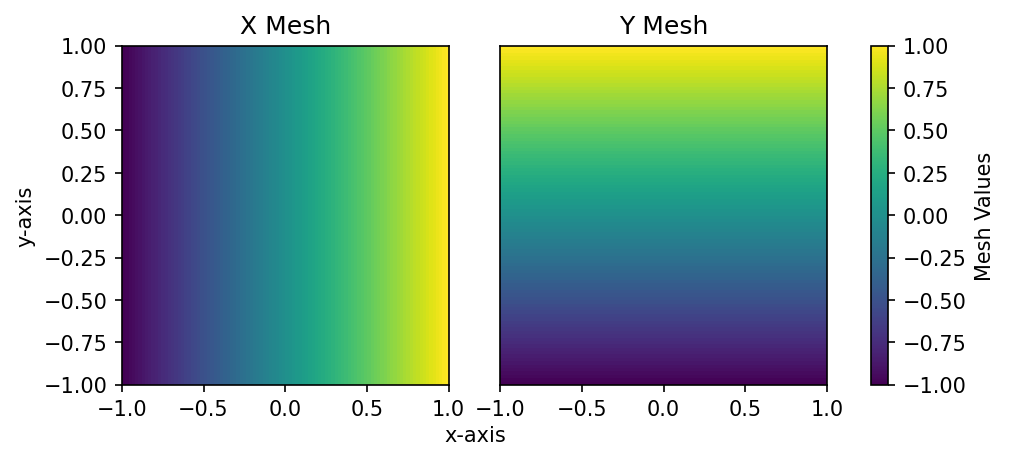

In [112]:
# First, construct the "true" data.
N = 3
coeffs = np.array([-1.3, np.pi, 2, -0.7])
x_vals = np.linspace(-1, 1, 100)
y_vals = np.linspace(-1, 1, 100)

# We need to compute the polynomial on the *mesh* of (x,y) points:
X, Y = np.meshgrid(x_vals, y_vals)
# First, check that the meshes were made correctly.
norm = plt.cm.colors.Normalize(vmin=-1, vmax=1)
cmap = plt.cm.viridis
smap = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
extent = (-1, 1, -1, 1)
fig, axes = plt.subplots(1, 2, figsize=(7,3), dpi=150)
axes[0].imshow(X, aspect="auto", origin="lower", extent=extent, cmap=cmap, norm=norm)
axes[1].imshow(Y, aspect="auto", origin="lower", extent=extent, cmap=cmap, norm=norm)
axes[0].set_title("X Mesh")
axes[1].set_title("Y Mesh")
axes[1].yaxis.set_visible(False)
fig.text(0.46, 0.015, "x-axis", ha="center", va="center")
axes[0].set_ylabel("y-axis")
fig.tight_layout()
fig.colorbar(smap, ax=axes, label="Mesh Values")
plt.show()

This looks good! The X mesh increases along the x-axis, while the Y mesh increases along the y-axis. I find that whenever I am working with a coordinate mesh, it is helpful to first make plots like this to check that I have set up the meshes correctly. Now to evaluate the polynomial and construct the data.

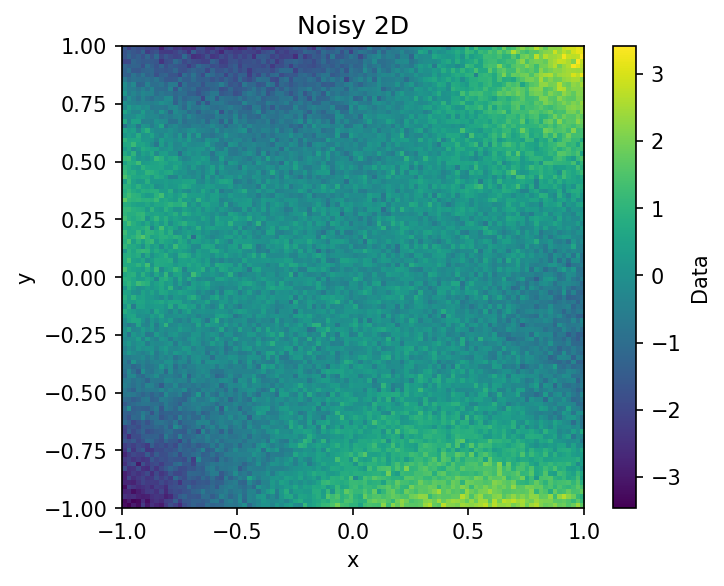

In [113]:
# Your code here; use the code from Section 2.1 as an example to build on.
# I'll only fill in a few small things--the rest is up to you.

# Evaluate the polynomial.
#z = a0Y^3+a1^xy^2+a2x^2y+a3x^3
true_data = (coeffs[0]*Y**3+coeffs[1]*X*Y**2+coeffs[2]*X**2*Y+coeffs[3]*X**3)
# Add noise.
var = 0.1
noisy_data = true_data + np.random.normal(loc=0,scale=np.sqrt(var),size=true_data.shape)
# Take a look at the data. Does it look sensible?
plt.figure(figsize=(5,4), dpi=150)
plt.imshow( noisy_data,origin="lower",extent=(-1,1,-1,1))
plt.colorbar(label="Data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy 2D")
plt.savefig("noisy_2d_polynomial.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [114]:
# Now find the best-fit solution. First, flatten (or vectorize)
# the meshes and the data to turn this into a linear problem.
x_flat = X.flatten()
y_flat = Y.flatten()
noisy_flat = noisy_data.flatten() 
# Create the design matrix.
A = np.zeros((x_flat.size,4 ))
A[:,0] = y_flat**3
A[:,1] = x_flat*y_flat**2
A[:,2] = x_flat**2*y_flat
A[:,3] = x_flat**3
# Find the best-fit polynomial coefficients.
"""Assume the inverse of N have uniform weighting, so it is an identity matrix"""
best_fit_coeffs = np.linalg.inv(A.T @ A) @ A.T @ noisy_flat
# Compare your fit against the input values.
print("True data coeffs :", coeffs)
print("Fvest fit model coeffs:", best_fit_coeffs)

True data coeffs : [-1.3         3.14159265  2.         -0.7       ]
Fvest fit model coeffs: [-1.30920302  3.14783151  2.03676715 -0.69397382]


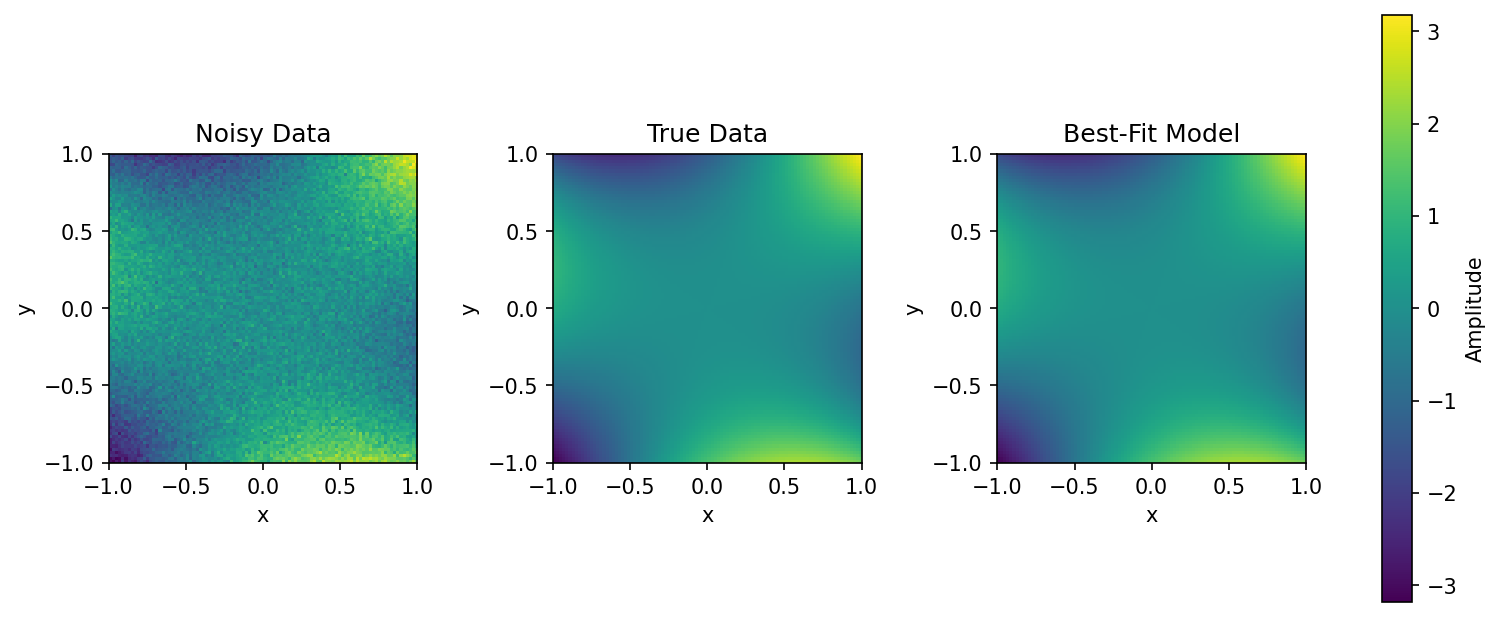

In [115]:
"""recover the underlying signal while ignoring noise."""
model = A @ best_fit_coeffs
model_2d = model.reshape(X.shape)
fig, axes = plt.subplots(1, 3,figsize=(10,4),dpi=150,constrained_layout=True)

# Noisy data
im0 = axes[0].imshow(noisy_data,origin="lower",extent=(-1,1,-1,1))
axes[0].set_title("Noisy Data")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

#True data
im0 = axes[1].imshow(true_data,origin="lower",extent=(-1,1,-1,1))
axes[1].set_title("True Data")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# Best-fit model
im1 = axes[2].imshow(model_2d,origin="lower",extent=(-1,1,-1,1))
axes[2].set_title("Best-Fit Model")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

# Shared colorbar
fig.colorbar(im1, ax=axes, label="Amplitude")
plt.savefig("2d_polynomial_fit_comparison.pdf", format="pdf", bbox_inches="tight")

plt.show()

True coeffs: [-1.3         3.14159265  2.         -0.7       ]
Fitted coeffs: [-1.30920302  3.14783151  2.03676715 -0.69397382]
Reduced chi-squared: 1.0178864645647225


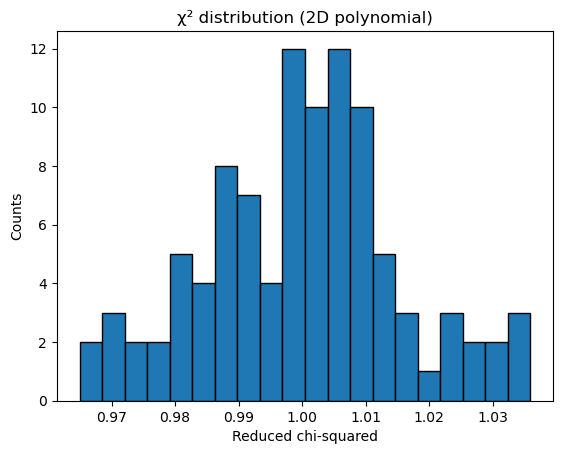

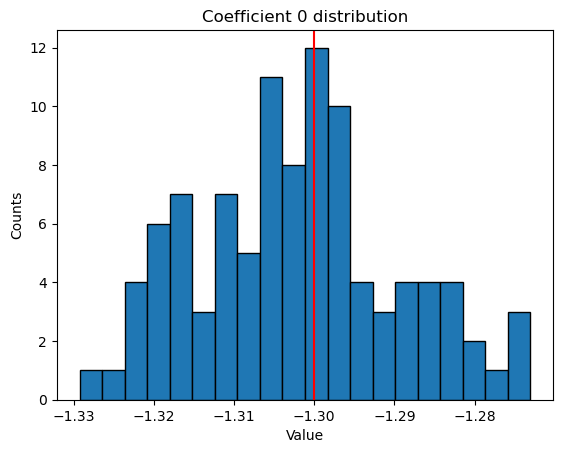

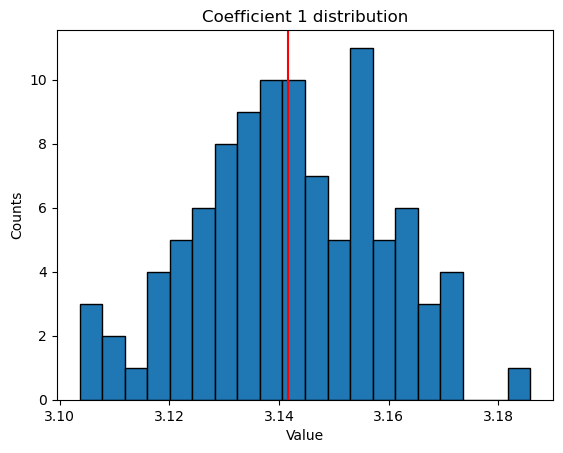

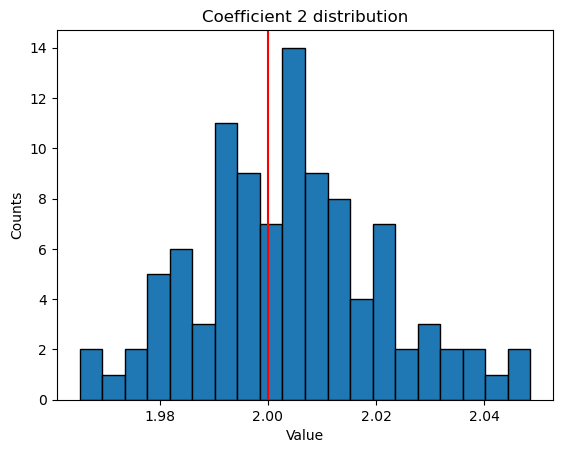

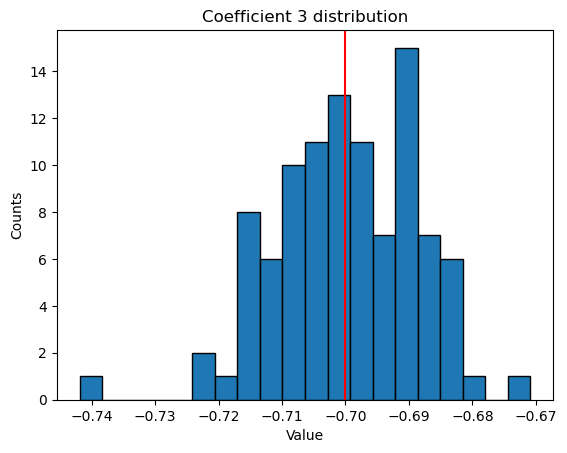

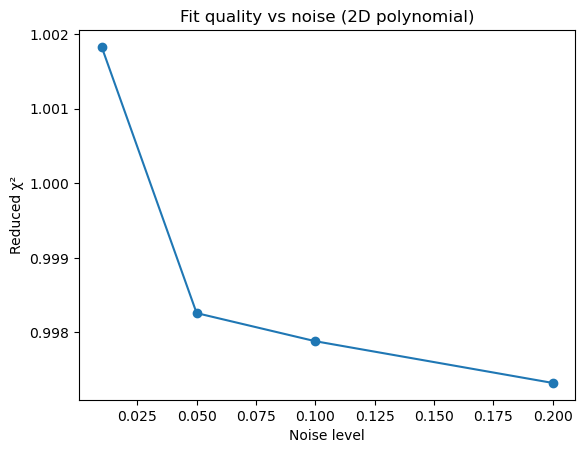

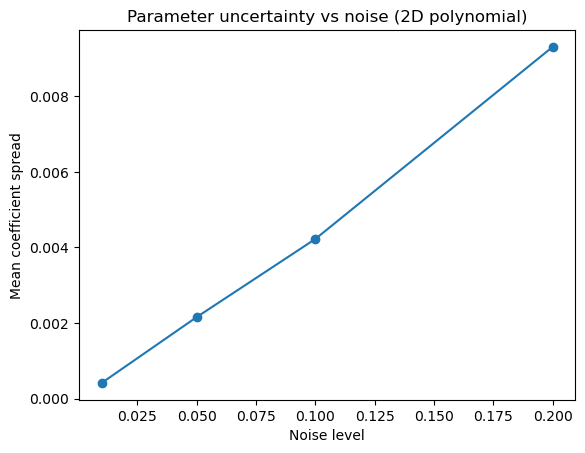

In [116]:
def fit_2d_poly(X, Y, data):
    x_flat = X.flatten()
    y_flat = Y.flatten()
    data_flat = data.flatten()

    A = np.zeros((x_flat.size, 4))
    A[:, 0] = y_flat**3
    A[:, 1] = x_flat * y_flat**2
    A[:, 2] = x_flat**2 * y_flat
    A[:, 3] = x_flat**3

    coeffs_fit = np.linalg.lstsq(A, data_flat, rcond=None)[0]

    model = A @ coeffs_fit
    model_2d = model.reshape(X.shape)

    return coeffs_fit, model_2d

# Single fit example
coeffs_fit, model_2d = fit_2d_poly(X, Y, noisy_data)
print("True coeffs:", coeffs)
print("Fitted coeffs:", coeffs_fit)
noise_flat = noisy_data.flatten()
model_flat = model_2d.flatten()
sigma = np.sqrt(var)
chi2 = np.sum(((noise_flat - model_flat) / sigma) ** 2)
dof = noise_flat.size - 4
chi2_red = chi2 / dof
print("Reduced chi-squared:", chi2_red)

# Monte Carlo: coefficient + chi2 distribution
N = 100
chi2_list = []
coeffs_list = []

for i in range(N):

    noisy = true_data + np.random.normal(0, np.sqrt(var), size=true_data.shape)

    coeffs_fit, model_2d = fit_2d_poly(X, Y, noisy)

    coeffs_list.append(coeffs_fit)

    residuals = noisy.flatten() - model_2d.flatten()

    chi2 = np.sum((residuals / np.sqrt(var)) ** 2)
    dof = noisy.size - 4

    chi2_list.append(chi2 / dof)

# FIG 1: chi2 distribution
plt.hist(chi2_list, bins=20, edgecolor="k")
plt.xlabel("Reduced chi-squared")
plt.ylabel("Counts")
plt.title("χ² distribution (2D polynomial)")
plt.savefig("2dpoly_chi2_distribution.pdf", bbox_inches="tight")
plt.show()

# FIG 2–5: coefficient distributions
coeffs_list = np.array(coeffs_list)
for i in range(4):
    plt.hist(coeffs_list[:, i], bins=20, edgecolor="k")
    plt.axvline(coeffs[i], color='r')
    plt.title(f"Coefficient {i} distribution")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.savefig(f"2dpoly_coeff_{i}_distribution.pdf", bbox_inches="tight")
    plt.show()
    
# Noise study

noise_levels = [0.01, 0.05, 0.1, 0.2]

chi2_means = []
coeff_spread = []

for sigma in noise_levels:

    chi2_vals = []
    coeff_vals = []

    for i in range(50):

        noisy = true_data + np.random.normal(0, sigma, size=true_data.shape)

        coeffs_fit, model_2d = fit_2d_poly(X, Y, noisy)

        coeff_vals.append(coeffs_fit)

        residuals = noisy.flatten() - model_2d.flatten()

        chi2 = np.sum((residuals / sigma) ** 2)
        dof = noisy.size - 4

        chi2_vals.append(chi2 / dof)

    chi2_means.append(np.mean(chi2_vals))
    coeff_spread.append(np.std(coeff_vals, axis=0))

# FIG 6: chi2 vs noise
plt.plot(noise_levels, chi2_means, marker='o')
plt.xlabel("Noise level")
plt.ylabel("Reduced χ²")
plt.title("Fit quality vs noise (2D polynomial)")
plt.savefig("2dpoly_chi2_vs_noise.pdf", bbox_inches="tight")
plt.show()

# FIG 7: parameter uncertainty vs noise
plt.plot(noise_levels, np.mean(coeff_spread, axis=1), marker='o')
plt.xlabel("Noise level")
plt.ylabel("Mean coefficient spread")
plt.title("Parameter uncertainty vs noise (2D polynomial)")
plt.savefig("2dpoly_coeff_spread_vs_noise.pdf", bbox_inches="tight")
plt.show()

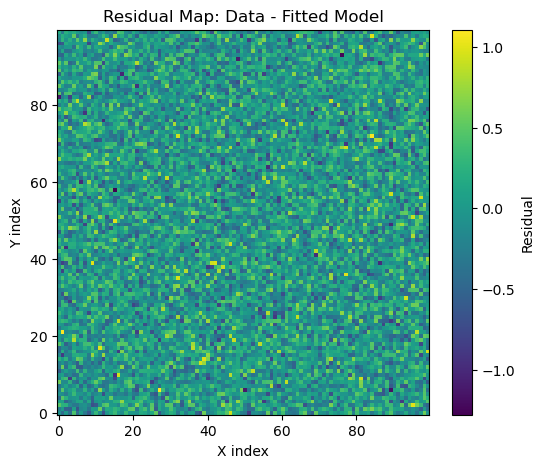

In [118]:
residual_map = noisy_data - model_2d
plt.figure(figsize=(6, 5))
im = plt.imshow(
    residual_map,
    origin='lower',
    aspect='auto'
)
plt.colorbar(im, label="Residual")
plt.title("Residual Map: Data - Fitted Model")
plt.xlabel("X index")
plt.ylabel("Y index")
plt.savefig("2dpoly_residual_map.pdf", bbox_inches="tight")
plt.show()

In [117]:
sigma2 = var  # noise variance
residuals = noisy_flat - (A @ best_fit_coeffs)
chi2 = np.sum((residuals**2) / sigma2)
dof = len(noisy_flat) - len(coeffs)
chi2_red = chi2 / dof
print("Chi2:", chi2)
print("DOF:", dof)
print("Reduced chi2:", chi2_red)

Chi2: 10174.793099788969
DOF: 9996
Reduced chi2: 1.0178864645647228


## Nonlinear Least-Squares

Sometimes our model of the data is not a linear operation acting on our set of model parameters. What this means is that we cannot solve the problem directly by just doing a bunch of matrix operations on the data, and we need to find another way to minimize $\chi^2$. For reference, let's remind ourselves of how $\chi^2$ looks in the general case:  
  
$$
    \chi^2 = \sum_i \frac{|d_i - m_i(\vec{\theta})|^2}{\sigma_i^2}.
$$  
  
Remember the goal is that we want to determine the set of parameters $\{\hat{\theta}_j\}$ that recover the smallest possible value of $\chi^2$ given the data $\{d_i\}$. There are a number of ways we can do this, but they all kind of boil down to a simple idea: **try out a bunch of different values for $\vec{\theta}$ and choose the ones that give the lowest value of $\chi^2$**. The most straightforward way is to perform a *grid search*, where we set up a grid of model parameters, evaluate $\chi^2$ at each point in that grid, and then choose the point that has the lowest value of $\chi^2$. This approach, however, is extremely inefficient and is only tractable for a very, very small class of problems. (While this is very inefficient in the grand scheme, it is sometimes the preferred approach. One example is refining localizations for fast radio bursts, where you already have a decent idea of where the burst is coming from but want to work out precisely which part of your localization gives the best fit.) We can make the search through the parameter space $\{\theta_j\}$ a bit more efficient by remembering the following fact:  
  
**The gradient of a function points in the direction that a function is increasing.**  
  
So, if we can compute the gradient of $\chi^2$, then we can figure out where we should move in parameter space to find a new set of parameters that better describe our data. This is the big idea behind *gradient descent*, where we try out one point in parameter space, compute the gradient at that point, then move in the opposite direction to get closer to the minimum. The details are more complicated (e.g., How do I know how big of a step in parameter space that I should take? How do I minimize the number of steps I need to take in a particular direction? How can I be sure I've hit the minimum?), but we won't get into any of that&mdash;the basic idea I want you to take away from this is that we can figure out how to minimize $\chi^2$ if we have a reasonable initial guess at the best-fit parameters and we know how to compute $\chi^2$ as well as its gradient with respect to the model parameters. The folks at `scipy` have done a ton of great work that allows us to basically not think about the complicating details *most* of the time, and we'll be using their optimization tools to obtain our fits.

Before jumping into some examples and practice exercises, I'll just quickly write down the general form of the gradient of $\chi^2$:  
  
$$
\begin{align}
    \frac{\partial\chi^2}{\partial\theta_j} &= \frac{\partial}{\partial\theta_j} \sum_i \frac{|d_i - m_i(\vec{\theta})|^2}{\sigma_i^2} \\
    &= -2\sum_i \frac{d_i - m_i(\vec{\theta})}{\sigma_i^2} \frac{\partial m_i(\vec{\theta})}{\partial\theta_j}.
\end{align}
$$

### A Power Law, Again

In a previous section, we fit for a power law by linearizing the problem and employing linear least-squares to find the best-fit solution. Let's now use *nonlinear* least-squares to find the best-fit solution. Remember that for a power law, our model is  
  
$$
    m_i(S_0, \beta) = S_0 (\nu_i/\nu_0)^{-\beta},
$$
  
so $\chi^2$ can be written as  
  
$$
    \chi^2 = \sum_i \frac{(d_i - S_0(\nu_i/\nu_0)^{-\beta})^2}{\sigma_i^2}.
$$  
  
In order to apply nonlinear least-squares, we need to compute the derivative of the model with respect to the model parameters $S_0,\beta$. Remember that the derivative of an exponential is  
  
$$
    \frac{{\rm d} a^x}{{\rm d}x} = a^x \ln a,
$$  
  
so the two components of the $\chi^2$ gradient are  
  
$$
\begin{align}
    \frac{\partial \chi^2}{\partial S_0} &= -2 \sum_i \frac{d_i - S_0 (\nu_i/\nu_0)^{-\beta}}{\sigma_i^2} (\nu_i/\nu_0)^{-\beta}, \\
    \frac{\partial \chi^2}{\partial \beta} &= 2 \sum_i \frac{d_i - S_0 (\nu_i/\nu_0)^{-\beta}}{\sigma_i^2} S_0 (\nu_i/\nu_0)^{-\beta} \ln(\nu_i/\nu_0).
\end{align}
$$  
  
Algorithmically, it's a little easier to rewrite this in terms of the model $m_i(S_0,\beta)$ via  
  
$$
\begin{align}
    \frac{\partial \chi^2}{\partial S_0} &= -2 \sum_i \frac{d_i - m_i(S_0,\beta)}{\sigma_i^2} \frac{m_i(S_0, \beta)}{S_0}, \\
    \frac{\partial \chi^2}{\partial \beta} &= 2 \sum_i \frac{d_i - m_i(S_0,\beta)}{\sigma_i^2} m_i(S_0, \beta) \ln(\nu_i/\nu_0).
\end{align}
$$
  
Let's get to implementing this.

In [127]:
# First, define our model function.
def power_law(nu, S_0=1, beta=1, nu_0=150):
    """Evaluate a power law in frequency.
    
    Parameters
    ----------
    nu: array of float
        Frequencies at which to evaluate the model, in MHz.
    S_0: float
        Flux at the reference frequency nu_0, in Jy.
    beta: float
        Spectral index.
    nu_0: float
        Reference frequency, in MHz.
        
    Returns
    -------
    exp_flux: array of float
        Expected flux at the provided frequencies.
    """
    return S_0 * (nu/nu_0)**-beta

# Now define chi-squared; the arguments might seem a little backwards,
# but remember we're thinking of chi-squared as a function of the model
# parameters, given the data. For now, we're using uniform weighting.
def chisq(model_params, data=None, nu=None, nu_0=150):
    """Evaluate chi-squared for a power-law model.
    
    Parameters
    ----------
    model_params: array of float
        Parameters characterizing the power-law. `model_params[0]` is the
        flux scale S_0 in Jy; `model_params[1]` is the spectral index.
    data: array of float
        Measured data values, in Jy.
    nu: array of float
        Frequencies at which the data was taken, in MHz.
    nu_0: float
        Reference frequency, in MHz.
        
    Returns
    -------
    chisq: float
        Sum of the squares of the residuals between the data and model.
    """
    # First, do some parameter checking to make sure we have enough information.
    if nu is None:
        raise ValueError("You must provide the observed frequencies!")
    if data is None:
        raise ValueError("Residuals cannot be computed without the data!")
        
    # Evaluate the model.
    S_0, beta = model_params
    model = power_law(nu, S_0=S_0, beta=beta, nu_0=nu_0)
    
    # Compute the residuals and return the sum of their squares.
    residuals = data - model
    return residuals @ residuals

def grad_chisq(model_params, data=None, nu=None, nu_0=150):
    """Evaluate the gradient of chi-squared for a power-law model.
    
    Parameters
    ----------
    model_params: array of float
        Parameters characterizing the power-law. `model_params[0]` is the
        flux scale S_0 in Jy; `model_params[1]` is the spectral index.
    data: array of float
        Measured data values, in Jy.
    nu: array of float
        Frequencies at which the data was taken, in MHz.
    nu_0: float
        Reference frequency, in MHz.
        
    Returns
    -------
    grad_chisq: array of float
        Gradient with respect to S_0 and beta.
    """
    # This isn't great code design, but we're not being too rigorous here,
    # so we'll just reuse the parameter-checking code.
    if nu is None:
        raise ValueError("You must provide the observed frequencies!")
    if data is None:
        raise ValueError("Residuals cannot be computed without the data!")
        
    # Make an array where we'll store the gradient values.
    gradient = np.zeros(2, dtype=float)
    # gradient[0] = derivative w.r.t. flux scale
    # gradient[1] = derivative w.r.t. spectral index
    
    # Evaluate the model for the given parameters.
    S_0, beta = model_params
    model = power_law(nu, S_0=S_0, beta=beta, nu_0=nu_0)
    
    # Compute the residuals.
    residuals = data - model
    
    # Now fill in the terms in the gradient with the expressions derived above.
    gradient[0] = -2 * residuals @ model / S_0
    gradient[1] = 2 * residuals @ (model * np.log(nu/nu_0))
    return gradient

In [128]:
# Now let's mock up some data
obs_freqs = np.linspace(100, 200, 301)
ref_freq = 150
true_flux_scale = 10
true_spectral_index = 2
true_data = power_law(
    obs_freqs, S_0=true_flux_scale, beta=true_spectral_index, nu_0=ref_freq
)
obs_data = true_data * (
    1 + np.random.normal(size=true_data.size, loc=0, scale=0.03)
)

# Now pick an initial guess at the best-fit parameters
init_guess = np.array([9, 2.3])
# Now run the optimizer!
results = minimize(
    fun=chisq,  # We want to minimize chi-squared.
    x0=init_guess,  # We're starting the optimizer here.
    args=(obs_data, obs_freqs, ref_freq),  # Extras to evaluate chisq, in the order the function expects.
    jac=grad_chisq,  # The Jacobian is just the gradient for this case.
    method="CG",  # Use the conjugate-gradient solver.
)

In [129]:
# Let's look at the results of the fit!
print(results)

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 37.591859353493305
       x: [ 9.981e+00  1.995e+00]
     nit: 10
     jac: [-4.772e-08 -1.713e-08]
    nfev: 22
    njev: 22


Here's how to interpret the above results:  
* fun: The value of $\chi^2$ at the best-fit values it settled on.
* jac: The value of $\nabla\chi^2$ at the best-fit values it found.
* message: Information about how well the fit performed.
* nfev: The number of times the minimizer evaluated $\chi^2$ when looking for the best-fit.
* nit: The number of iterations it took to find a solution.
* njev: The number of times the minimizer evaluated $\nabla\chi^2$ when looking for the best-fit.
* status: A boolean flag that depends on the success message. Sometimes it will "fail" but still give a good fit, so take it with a grain of salt.
* success: Whether or not the minimizer actually thinks it found the best-fit solution.
* x: The best-fit values it found.

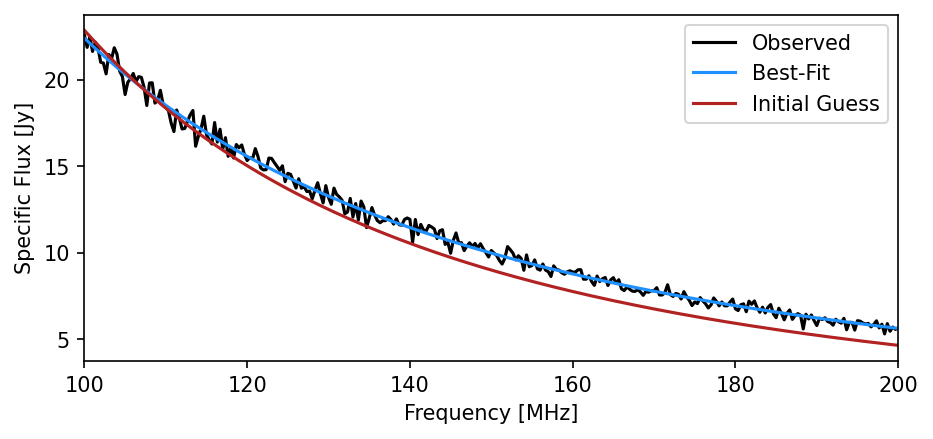

In [130]:
best_fit_flux_scale, best_fit_spectral_index = results.x
best_fit_model = power_law(
    obs_freqs, S_0=best_fit_flux_scale, beta=best_fit_spectral_index, nu_0=ref_freq
)
init_model = power_law(
    obs_freqs, S_0=init_guess[0], beta=init_guess[1], nu_0=ref_freq
)

fig, ax = plt.subplots(1, 1, figsize=(7,3), dpi=150)
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("Specific Flux [Jy]")
ax.plot(obs_freqs, obs_data, color="k", label="Observed")
ax.plot(obs_freqs, best_fit_model, color="dodgerblue", label="Best-Fit")
ax.plot(obs_freqs, init_model, color="firebrick", label="Initial Guess")
ax.legend()
ax.set_xlim(obs_freqs[0], obs_freqs[-1])
plt.savefig("nonlinear_powerlaw_fit.pdf", format="pdf", bbox_inches="tight")
plt.show()

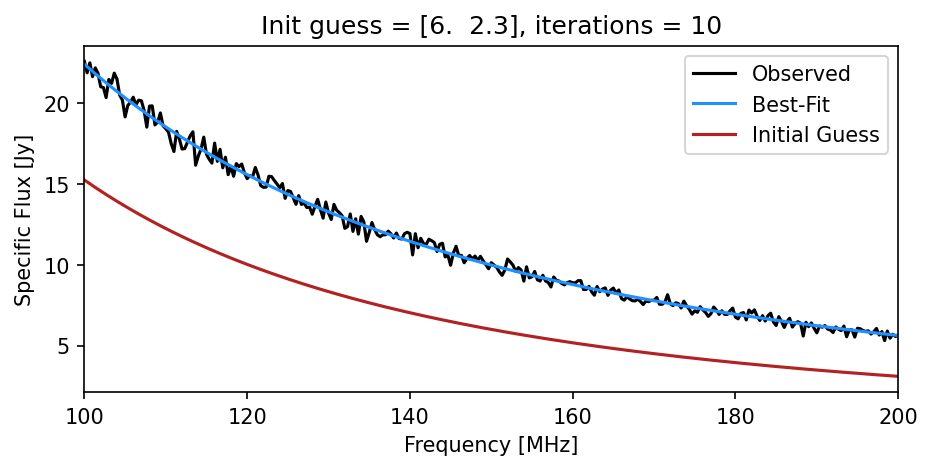

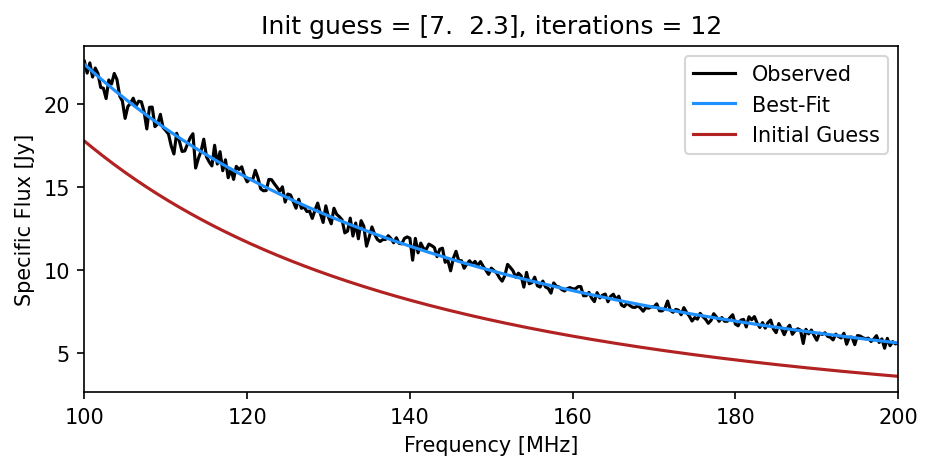

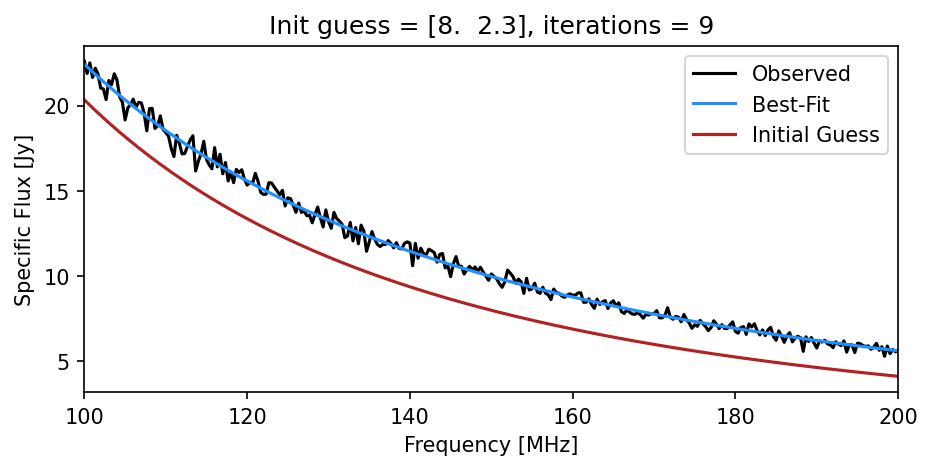

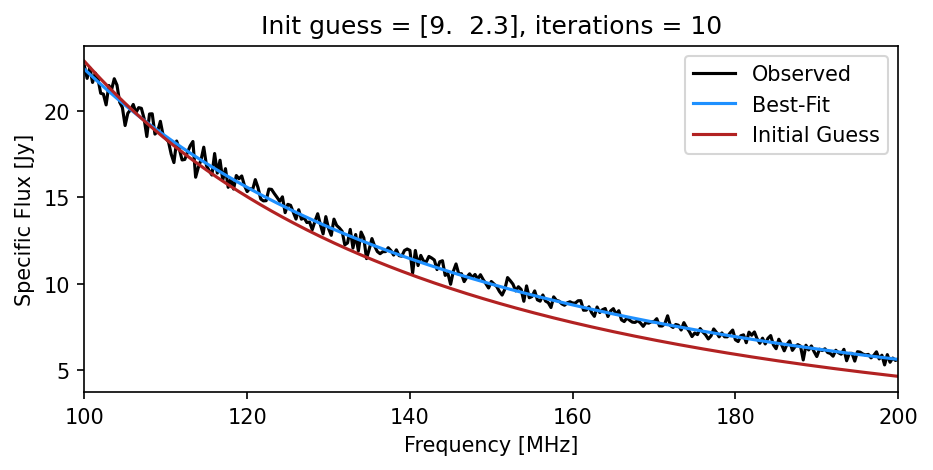

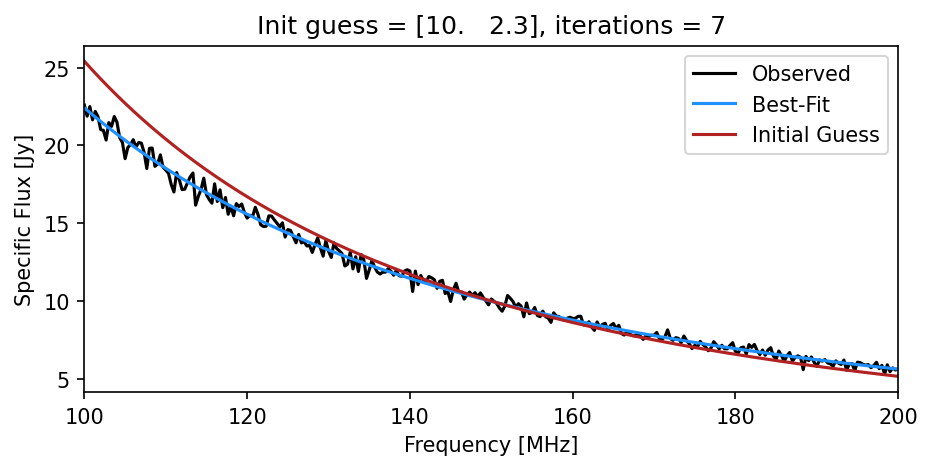

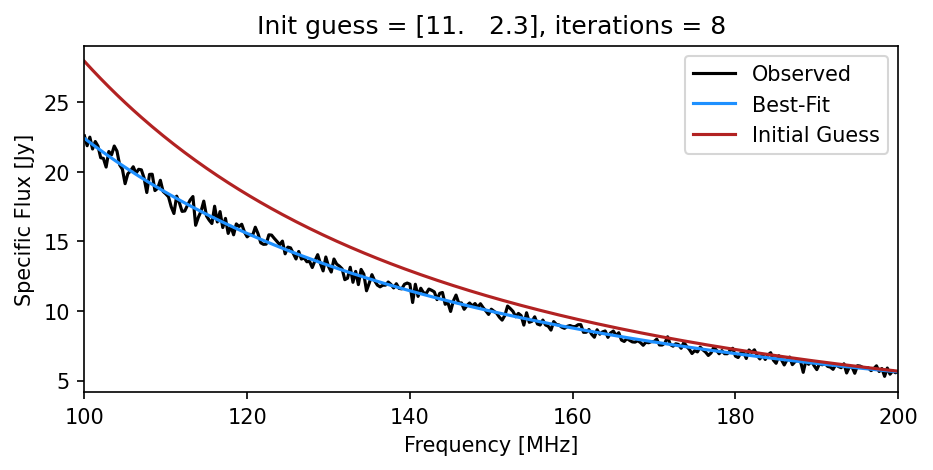

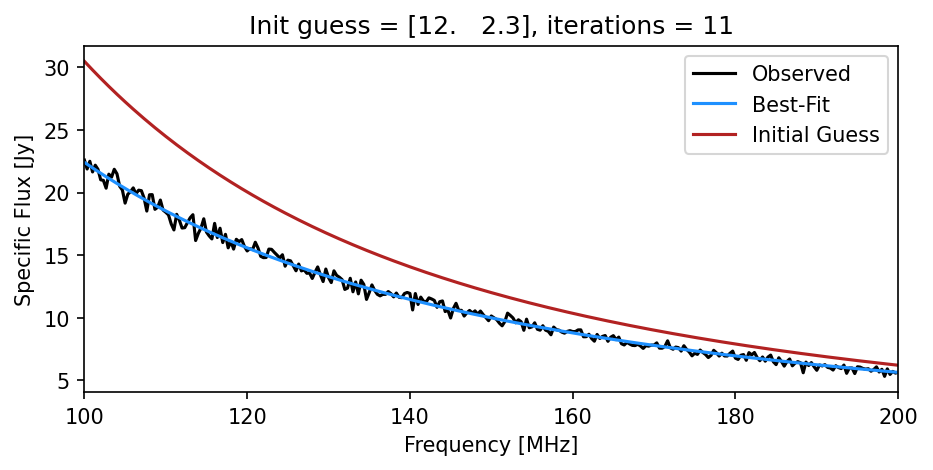

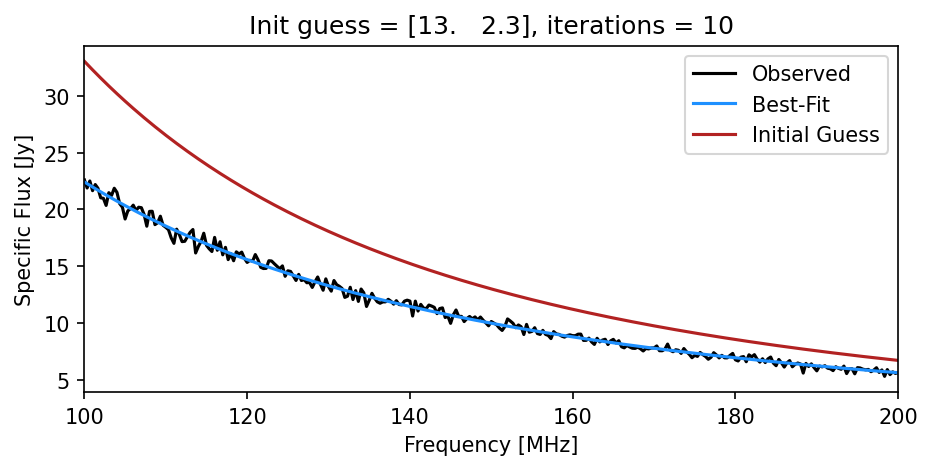

In [131]:
init_guesses = [
    np.array([6, 2.3]),
    np.array([7, 2.3]),
    np.array([8, 2.3]),
    np.array([9, 2.3]),
    np.array([10, 2.3]),
    np.array([11, 2.3]),
    np.array([12, 2.3]),
    np.array([13, 2.3])
]
for i, init_guess in enumerate(init_guesses):

    results = minimize(
        fun=chisq,
        x0=init_guess,
        args=(obs_data, obs_freqs, ref_freq),
        jac=grad_chisq,
        method="CG"
    )
    best_fit_flux, best_fit_beta = results.x
    best_fit_model = power_law(
        obs_freqs,
        S_0=best_fit_flux,
        beta=best_fit_beta,
        nu_0=ref_freq
    )
    init_model = power_law(
        obs_freqs,
        S_0=init_guess[0],
        beta=init_guess[1],
        nu_0=ref_freq
    )
    fig, ax = plt.subplots(1, 1, figsize=(7,3), dpi=150)
    ax.plot(obs_freqs, obs_data, color="k", label="Observed")
    ax.plot(obs_freqs, best_fit_model, color="dodgerblue", label="Best-Fit")
    ax.plot(obs_freqs, init_model, color="firebrick", label="Initial Guess")
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Specific Flux [Jy]")
    ax.set_title(f"Init guess = {init_guess}, iterations = {results.nit}")
    ax.legend()
    ax.set_xlim(obs_freqs[0], obs_freqs[-1])
    plt.savefig(f"powerlaw_initguess_{i}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

Reduced chi2: 0.963148197701456
Iterations: 8


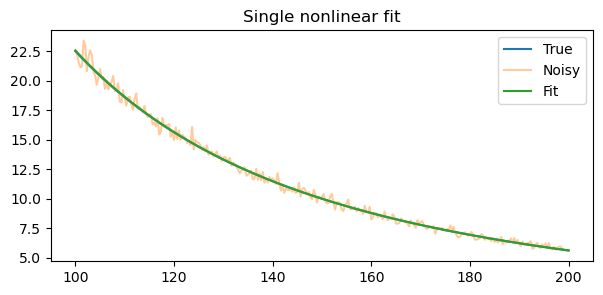

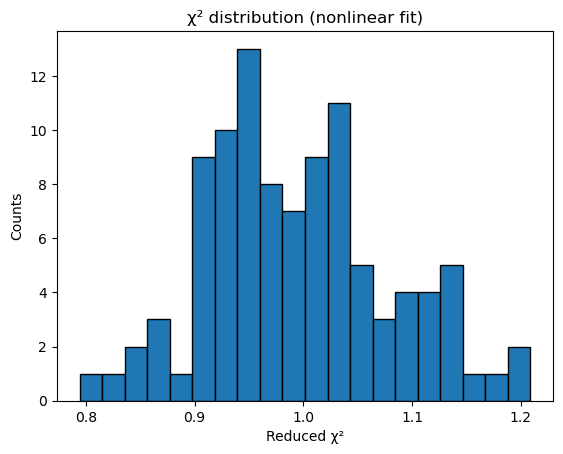

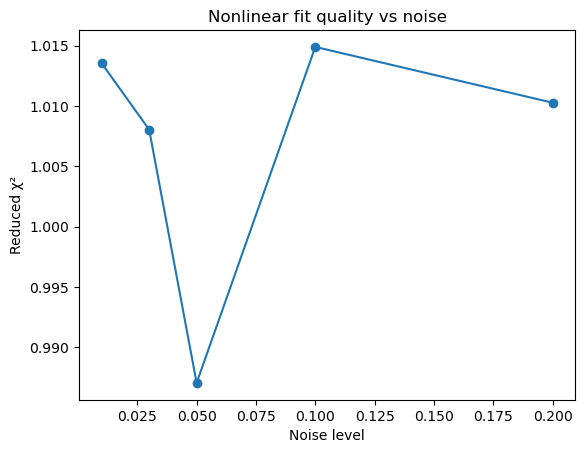

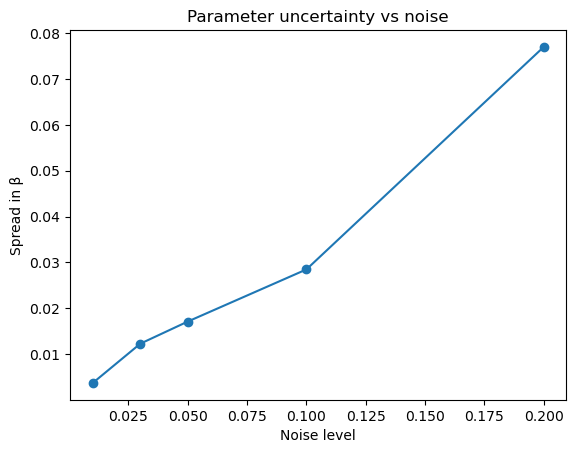

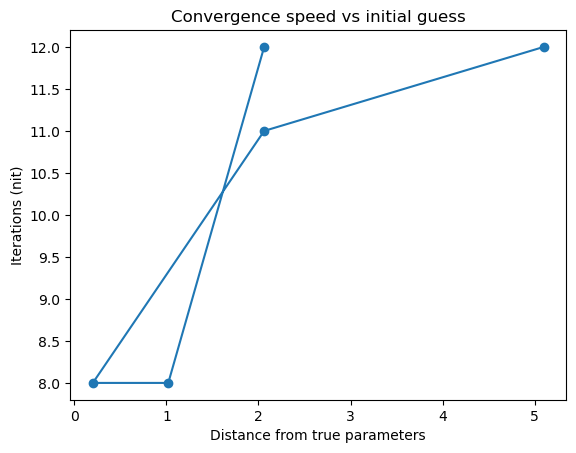

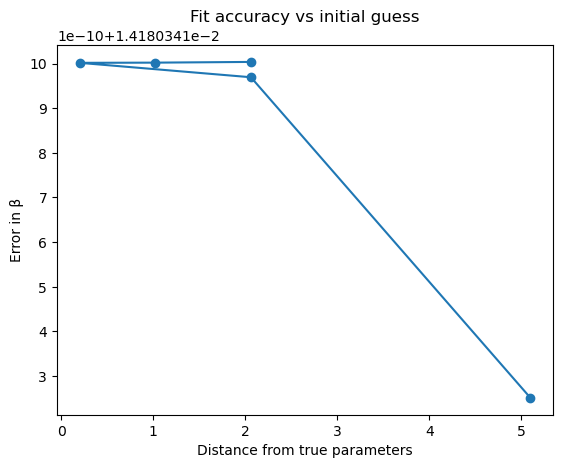

In [132]:
def chisq(params, data=None, nu=None, nu_0=150):
    S_0, beta = params
    model = power_law(nu, S_0=S_0, beta=beta, nu_0=nu_0)
    residuals = data - model
    return residuals @ residuals
# SETUP
obs_freqs = np.linspace(100, 200, 301)
ref_freq = 150

true_S0 = 10
true_beta = 2

true_data = power_law(obs_freqs, true_S0, true_beta, ref_freq)

noise_level = 0.03
dof = len(obs_freqs) - 2

init_guess = np.array([9, 2.3])

# 1) SINGLE FIT CHECK

obs_data = true_data * (1 + np.random.normal(0, noise_level, size=true_data.size))

res = minimize(
    chisq,
    x0=init_guess,
    args=(obs_data, obs_freqs, ref_freq),
    jac=grad_chisq,
    method="CG"
)

S0_fit, beta_fit = res.x
fit_model = power_law(obs_freqs, S0_fit, beta_fit, ref_freq)

sigma = noise_level * true_data
chi2 = np.sum(((obs_data - fit_model) / sigma) ** 2)

print("Reduced chi2:", chi2 / dof)
print("Iterations:", res.nit)

plt.figure(figsize=(7,3))
plt.plot(obs_freqs, true_data, label="True")
plt.plot(obs_freqs, obs_data, label="Noisy", alpha=0.4)
plt.plot(obs_freqs, fit_model, label="Fit")
plt.legend()
plt.title("Single nonlinear fit")
plt.savefig("single_nonlinear_fit.pdf", bbox_inches="tight")
plt.show()

# 2) CHI^2 DISTRIBUTION OVER NOISE REALIZATIONS

N = 100
chi2_list = []

for i in range(N):

    obs_data = true_data * (1 + np.random.normal(0, noise_level, size=true_data.size))

    res = minimize(
        chisq,
        x0=init_guess,
        args=(obs_data, obs_freqs, ref_freq),
        jac=grad_chisq,
        method="CG"
    )

    S0_fit, beta_fit = res.x
    fit = power_law(obs_freqs, S0_fit, beta_fit, ref_freq)

    chi2 = np.sum(((obs_data - fit) / sigma) ** 2)
    chi2_list.append(chi2 / dof)

plt.figure()
plt.hist(chi2_list, bins=20, edgecolor="k")
plt.xlabel("Reduced χ²")
plt.ylabel("Counts")
plt.title("χ² distribution (nonlinear fit)")
plt.savefig("nonlinear_chi2_hist.pdf", bbox_inches="tight")
plt.show()

# 3) NOISE DEPENDENCE STUDY

noise_levels = [0.01, 0.03, 0.05, 0.1, 0.2]

chi2_means = []
beta_spread = []

for sigma_frac in noise_levels:

    chi2_vals = []
    beta_vals = []

    for i in range(50):

        noisy = true_data * (1 + np.random.normal(0, sigma_frac, size=true_data.size))

        res = minimize(
            chisq,
            x0=init_guess,
            args=(noisy, obs_freqs, ref_freq),
            jac=grad_chisq,
            method="CG"
        )

        S0_fit, beta_fit = res.x
        beta_vals.append(beta_fit)

        fit = power_law(obs_freqs, S0_fit, beta_fit, ref_freq)

        chi2 = np.sum(((noisy - fit) / (sigma_frac * true_data)) ** 2)
        chi2_vals.append(chi2 / dof)

    chi2_means.append(np.mean(chi2_vals))
    beta_spread.append(np.std(beta_vals))

plt.figure()
plt.plot(noise_levels, chi2_means, marker='o')
plt.xlabel("Noise level")
plt.ylabel("Reduced χ²")
plt.title("Nonlinear fit quality vs noise")
plt.savefig("nonlinear_chi2_vs_noise.pdf", bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(noise_levels, beta_spread, marker='o')
plt.xlabel("Noise level")
plt.ylabel("Spread in β")
plt.title("Parameter uncertainty vs noise")
plt.savefig("beta_spread_vs_noise.pdf", bbox_inches="tight")
plt.show()

# 4) INITIAL GUESS STUDY (FIXED PROPERLY)
init_guesses = [
    [8, 1.5],
    [9, 1.8],
    [10, 2.2],
    [12, 2.5],
    [15, 3.0]
]

iterations = []
beta_errors = []

for guess in init_guesses:

    res = minimize(
        chisq,
        x0=np.array(guess),
        args=(obs_data, obs_freqs, ref_freq),
        jac=grad_chisq,
        method="CG"
    )

    iterations.append(res.nit)
    beta_errors.append(abs(res.x[1] - true_beta))

# distance from true guess (proper definition)
distances = [
    np.linalg.norm(np.array(g) - np.array([true_S0, true_beta]))
    for g in init_guesses
]

plt.figure()
plt.plot(distances, iterations, marker='o')
plt.xlabel("Distance from true parameters")
plt.ylabel("Iterations (nit)")
plt.title("Convergence speed vs initial guess")
plt.savefig("convergence_vs_initial_guess.pdf", bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(distances, beta_errors, marker='o')
plt.xlabel("Distance from true parameters")
plt.ylabel("Error in β")
plt.title("Fit accuracy vs initial guess")
plt.savefig("beta_error_vs_initial_guess.pdf", bbox_inches="tight")
plt.show()

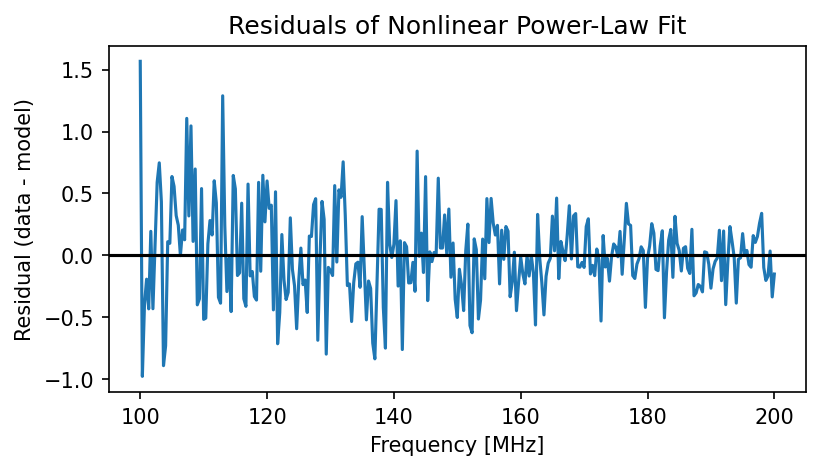

In [133]:
best_fit_model = power_law(obs_freqs,S_0=best_fit_flux_scale,beta=best_fit_spectral_index,nu_0=ref_freq)
residuals = obs_data - best_fit_model
plt.figure(figsize=(6,3), dpi=150)
plt.plot(obs_freqs, residuals)
plt.axhline(0, color='k')
plt.xlabel("Frequency [MHz]")
plt.ylabel("Residual (data - model)")
plt.title("Residuals of Nonlinear Power-Law Fit")
plt.savefig("nonlinear_power_law_residuals.pdf", bbox_inches="tight")
plt.show()

In [134]:
best_fit = results.x
model = power_law(obs_freqs,S_0=best_fit[0],beta=best_fit[1],nu_0=ref_freq)
residuals = obs_data - model
sigma = 0.03 * true_data  
chi2 = np.sum((residuals / sigma)**2)
dof = len(obs_data) - 2
chi2_red = chi2 / dof
print("Chi2:", chi2)
print("Reduced Chi2:", chi2_red)

Chi2: 297.2082123480936
Reduced Chi2: 0.9940073991575036


This looks like a pretty good fit to me! At any rate, it's certainly better than where we started! You should try experimenting with different initial guesses and see if there are some starting points where it isn't able to find a solution.

### A Polynomial in Two Dimensions

Let's return to the problem of a general polynomial in two dimensions:  
  
$$
    z = \Biggl(\sum_{i=1}^N \sum_{j=1}^M a_i b_j x^i y^j\Biggr) + n.
$$
  
While this can be written as a linear system in terms of some modified parameters, it is *nonlinear* in the polynomial coefficients $\{a_i,b_j\}$. In this case, we need to use an *iterative* algorithm for figuring out the set of model $\{a_i,b_j\}$ that minimizes $\chi^2$. `scipy` has a bunch of options available, but for now we'll restrict our attention to using the *conjugate gradient* solver. In order to use this, we need to provide the minimizer with a way of evaluating the objective function $\chi^2$, as well as its gradient. Let's work through the math.

Inserting our model into the expressions for $\chi^2$ and its gradient, we get the following:  
  
$$
\begin{align}
    \chi^2 &= \sum_k \sigma_k^{-2} \Bigg| d_k - \sum_{i=1}^N \sum_{j=1}^M a_i b_j x_k^i y_k^j \Bigg|^2, \\
    \frac{\partial\chi^2}{\partial\theta_n} &= -2 \sum_k \sigma_k^{-2} \Biggl( d_k - \sum_{i=1}^N \sum_{j=1}^M a_i b_j x_k^i y_k^j\Biggr) \Biggl( \sum_{i=1}^N \sum_{j=1}^M x_k^i y_k^j \frac{\partial(a_i b_j)}{\partial\theta_n} \Biggr).
\end{align}
$$
  
This is all a bit abstract, and is likely pretty confusing. For our polynomial case, $\theta_n \in \{a_1,\cdots,a_N,b_1,\cdots,b_M\}$, so the second double sum will collapse to a single sum. Let's make this a bit more concrete by limiting ourselves to considering $N = M = 1$, and simplify things by assuming the variance in the data is constant so $\sigma_k^2 = \sigma^2$.

In this limiting case, $\chi^2$ and its gradient become  
  
$$
\begin{align}
    \chi^2 &= \sigma^{-2} \sum_k \big| d_k - (a_0 b_0 + a_1 b_0 x_k + a_0 b_1 y_k + a_1 b_1 x_k y_k)\big|^2, \\
    \frac{\partial \chi^2}{\partial a_0} &= -2\sigma^{-2} \sum_k \bigl[d_k - (a_0 b_0 + a_1 b_0 x_k + a_0 b_1 y_k + a_1 b_1 x_k y_k)\bigr] (b_0 + b_1 y_k), \\
    \frac{\partial \chi^2}{\partial b_0} &= -2\sigma^{-2} \sum_k \bigl[d_k - (a_0 b_0 + a_1 b_0 x_k + a_0 b_1 y_k + a_1 b_1 x_k y_k)\bigr] (a_0 + a_1 x_k), \\
    \frac{\partial \chi^2}{\partial a_1} &= -2\sigma^{-2} \sum_k \bigl[d_k - (a_0 b_0 + a_1 b_0 x_k + a_0 b_1 y_k + a_1 b_1 x_k y_k)\bigr] (b_0 x_k + b_1 x_k y_k), \\
    \frac{\partial \chi^2}{\partial b_1} &= -2\sigma^{-2} \sum_k \bigl[d_k - (a_0 b_0 + a_1 b_0 x_k + a_0 b_1 y_k + a_1 b_1 x_k y_k)\bigr] (a_0 y_k + a_1 x_k y_k).
\end{align}
$$  
  
You should work through the math and verify that you get the same result.

This is already kind of a lot of work! I'm not going to bother coding this up, but I think it's useful to go through exercises like this to get a sense of what's involved in running nonlinear least-squares fits.

### Fitting a Sine Wave

Now for you to try a fitting problem! For this example, the underlying "truth" will be a sine wave  
  
$$
    m(A,\nu) = A\sin(2\pi\nu t),
$$
  
and our observed data will be a function of time. I am going to write down a bunch of comments describing things I would like you to code up; see if you can figure out how to implement the solver based on the power-law example.

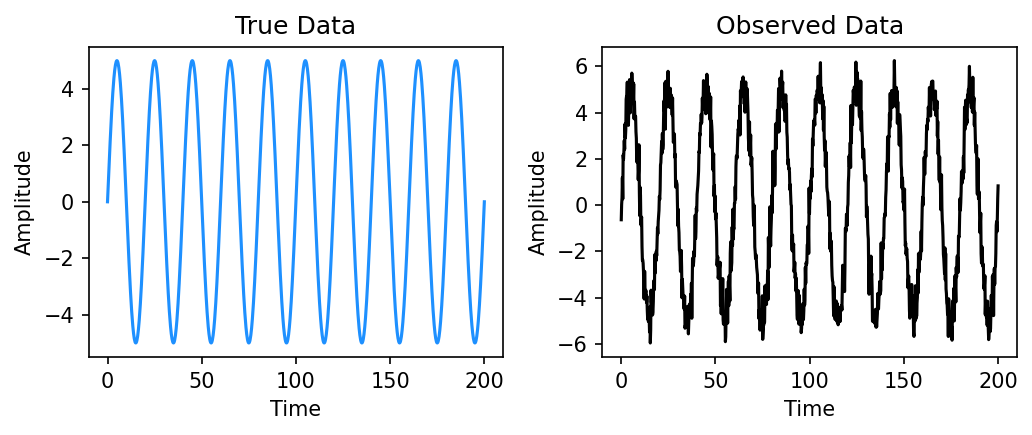

In [157]:
# Determine the true amplitude and frequency of the sine wave.
#true amplitude
A0 = 5
#true frequency
nu0 = 0.05
# Come up with a range of times and simulate the true data.
t = np.linspace(0, 200, 1000)
true_data = A0*np.sin(2*np.pi*nu0*t)
# Add a small amount of noise.
noisy_data = true_data + np.random.normal(0, 0.5, size=t.size) #why are we assuming the noise is from normal distribution
# Plot the true signal and the noisy signal.
fig, ax = plt.subplots(1, 2, figsize=(7,3), dpi=150)
# True data
ax[0].plot(t, true_data, color="dodgerblue")
ax[0].set_title("True Data")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Amplitude")
# Noisy data
ax[1].plot(t, noisy_data, color="k")
ax[1].set_title("Observed Data")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Amplitude")
plt.tight_layout()
plt.savefig("sine_true_vs_noisy.pdf", format="pdf", bbox_inches="tight")
plt.show()

Is the noise level sufficiently low that you can still make out a sine wave by eye? If not, then your minimizer is going to have a hard time.

In [158]:
# Define your model function. 
#unknown parameter:
t = np.linspace(0, 200, 1000)
model = A0*np.sin(2*np.pi*nu0*t)
def m(A,nu,t=t):
    return A*np.sin(2*np.pi*nu*t)
# Define a function for evaluating chi-squared.
def chisq(model_params, data=None ,t=None):
    """
    Compute chi-squared between observed data and sine model.
    Model:
        m(A, nu, t) = A * sin(2π nu t)
    Parameters
    ----------
    model_params : array-like, shape (2,)
        [A, nu] where:
        A   = amplitude
        nu  = frequency
    data : array-like
        Observed noisy data values.
    t : array-like
        Time samples corresponding to data.
    Returns
    -------
    float
        Sum of squared residuals between data and model.
    """
    if data is None:
        raise ValueError("Residuals cannot be computed without the data!")
    if t is None:
        raise ValueError("You cannot have no input of time")
    A, nu = model_params
    model = m(A = A, nu=nu,t=t)
    residuals = data - model
    return residuals @ residuals
    
# Define a function for evaluating the gradient of chi-squared.
def grad_chisq(model_params, data=None, t=None):
    """Compute gradient of chi-squared for sine wave model.
    Model:
        m(A, nu, t) = A * sin(2π nu t)
    Parameters
    ----------
    model_params : array-like, shape (2,)
        [A, nu] where:
        A   = amplitude
        nu  = frequency

    data : array-like
        Observed noisy data values.

    t : array-like
        Time samples corresponding to data.

    Returns
    -------
    ndarray, shape (2,)
        Gradient [dχ²/dA, dχ²/dnu]"""
    if data is None:
        raise ValueError("Residuals cannot be computed without the data!")
    if t is None:
        raise ValueError("You cannot have no input of time")
    gradient = np.zeros(2, dtype=float)
    A, nu = model_params
    model = m(A = A, nu=nu,t=t)
    residuals = data - model
    gradient[0] = -2 * np.sum(residuals * np.sin(2*np.pi*nu*t))
    gradient[1] = -2 * np.sum(residuals * A * np.cos(2*np.pi*nu*t) * (2*np.pi*t))
    return gradient
    
# Come up with an initial guess that is somewhat close to the true model parameters.    
init_guess = np.array([5,0.05])
# Run the minimizer with the conjugate-gradient solver.
results = minimize(
    fun=chisq,  
    x0=init_guess, 
    args=(noisy_data, t), 
    jac=grad_chisq, 
    method="BFGS",  
)
# Inspect the results of the fit.
print(results)
print("Best-fit parameters:", results.x)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 275.8541910577881
        x: [ 5.002e+00  5.000e-02]
      nit: 5
      jac: [-1.255e-08 -9.145e-06]
 hess_inv: [[ 1.001e-03  3.786e-09]
            [ 3.786e-09  7.581e-11]]
     nfev: 14
     njev: 14
Best-fit parameters: [5.00244121 0.05000223]


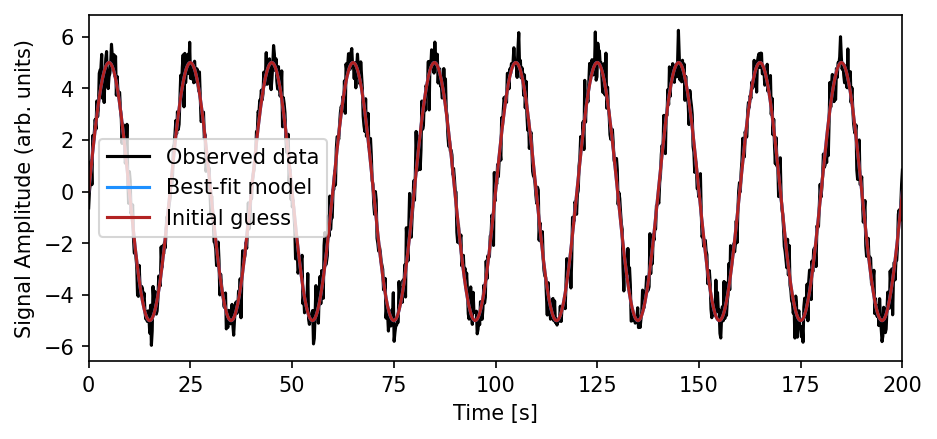

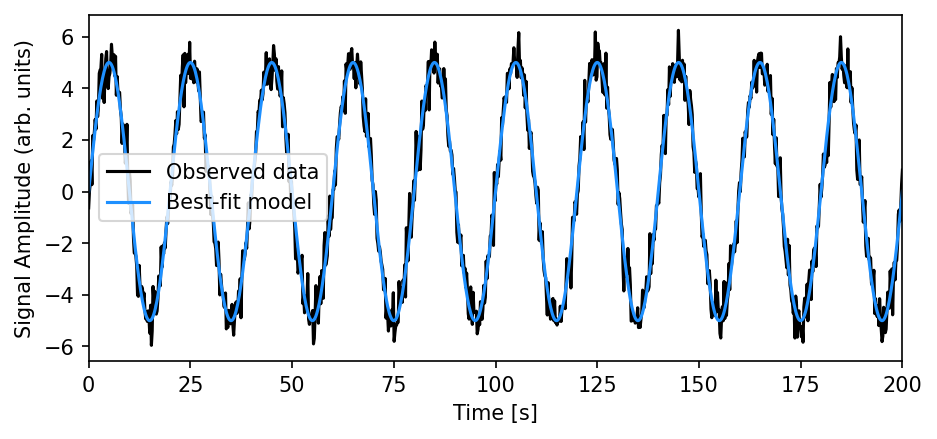

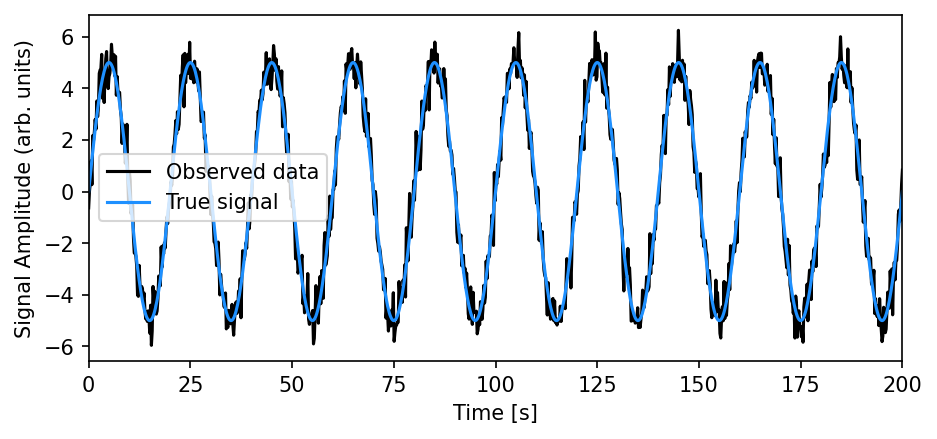

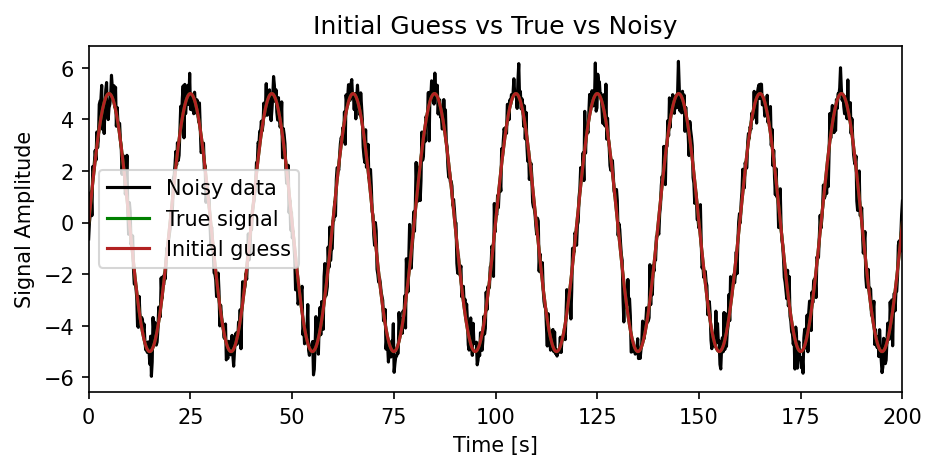

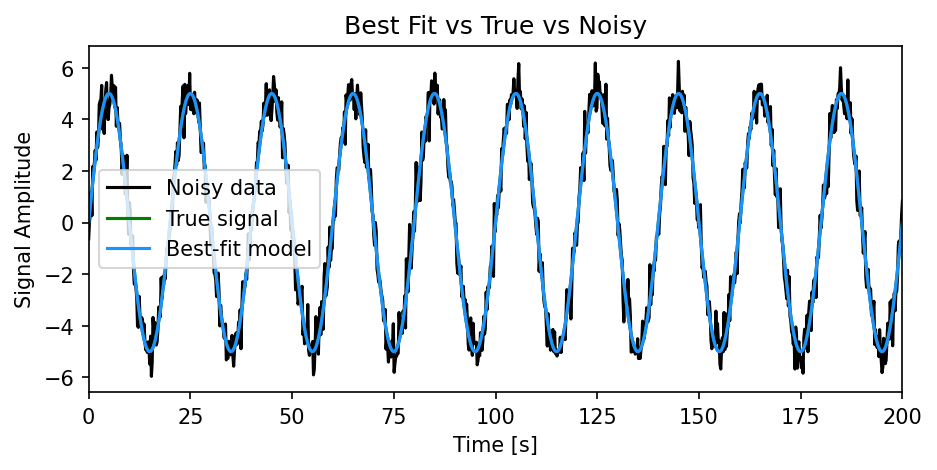

In [159]:
best_fit_amplitude, best_fit_nu = results.x
best_fit_model = m(best_fit_amplitude, best_fit_nu, t)
init_model = m(init_guess[0], init_guess[1], t)
# 1. Observed + Best fit + Initial guess
fig, ax = plt.subplots(1, 1, figsize=(7,3), dpi=150)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Signal Amplitude (arb. units)")
ax.plot(t, noisy_data, color="k", label="Observed data")
ax.plot(t, best_fit_model, color="dodgerblue", label="Best-fit model")
ax.plot(t, init_model, color="firebrick", label="Initial guess")
ax.legend()
ax.set_xlim(t[0], t[-1])
plt.savefig("sine_fit_init_vs_best.pdf", format="pdf", bbox_inches="tight")
plt.show()
# 2. Observed + Best fit only
fig, ax = plt.subplots(1, 1, figsize=(7,3), dpi=150)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Signal Amplitude (arb. units)")
ax.plot(t, noisy_data, color="k", label="Observed data")
ax.plot(t, best_fit_model, color="dodgerblue", label="Best-fit model")
ax.legend()
ax.set_xlim(t[0], t[-1])
plt.savefig("sine_fit_best_only.pdf", format="pdf", bbox_inches="tight")
plt.show()
# 3. Observed + True signal
fig, ax = plt.subplots(1, 1, figsize=(7,3), dpi=150)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Signal Amplitude (arb. units)")
ax.plot(t, noisy_data, color="k", label="Observed data")
ax.plot(t, true_data, color="dodgerblue", label="True signal")
ax.legend()
ax.set_xlim(t[0], t[-1])
plt.savefig("sine_true_vs_observed.pdf", format="pdf", bbox_inches="tight")
plt.show()

# 1. INITIAL GUESS vs TRUE vs NOISE
fig, ax = plt.subplots(1, 1, figsize=(7,3), dpi=150)
ax.plot(t, noisy_data, color="k", label="Noisy data")
ax.plot(t, true_data, color="g", label="True signal")
ax.plot(t, init_model, color="firebrick", label="Initial guess")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Signal Amplitude")
ax.set_title("Initial Guess vs True vs Noisy")
ax.legend()
ax.set_xlim(t[0], t[-1])
plt.savefig("sine_initial_guess_vs_true.pdf", bbox_inches="tight", format="pdf")
plt.show()

# 2. BEST FIT vs TRUE vs NOISE
fig, ax = plt.subplots(1, 1, figsize=(7,3), dpi=150)
ax.plot(t, noisy_data, color="k", label="Noisy data")
ax.plot(t, true_data, color="g", label="True signal")
ax.plot(t, best_fit_model, color="dodgerblue", label="Best-fit model")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Signal Amplitude")
ax.set_title("Best Fit vs True vs Noisy")
ax.legend()
ax.set_xlim(t[0], t[-1])
plt.savefig("sine_best_fit_vs_true.pdf", bbox_inches="tight", format="pdf")
plt.show()

In [160]:
sigma = 0.5 
residuals = noisy_data - best_fit_model
chi2 = np.sum((residuals / sigma) ** 2)
dof = len(t) - 2 
print("Reduced chi-squared:", chi2 / dof)
print("Iterations (nit):", results.nit)

Reduced chi-squared: 1.1056280202716962
Iterations (nit): 5


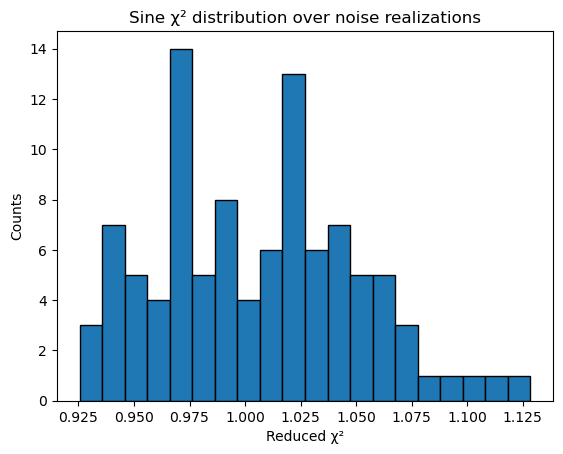

In [161]:
N = 100
chi2_list = []
for i in range(N):
    noisy_data = true_data + np.random.normal(0, 0.5, size=t.size)
    res = minimize(
        chisq,
        x0=init_guess,
        args=(noisy_data, t),
        jac=grad_chisq,
        method="BFGS"
    )
    A_fit, nu_fit = res.x
    fit_model = m(A_fit, nu_fit, t)
    residuals = noisy_data - fit_model
    chi2 = np.sum((residuals / 0.5) ** 2)
    chi2_list.append(chi2 / (len(t) - 2))
    
plt.hist(chi2_list, bins=20, edgecolor="k")
plt.xlabel("Reduced χ²")
plt.ylabel("Counts")
plt.title("Sine χ² distribution over noise realizations")
plt.savefig("sine_chi2_distribution.pdf")
plt.show()

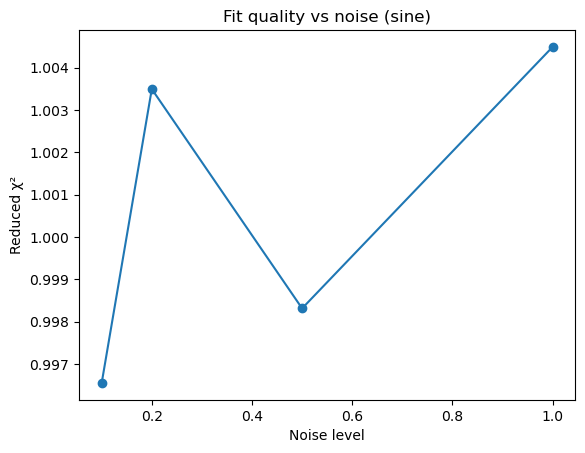

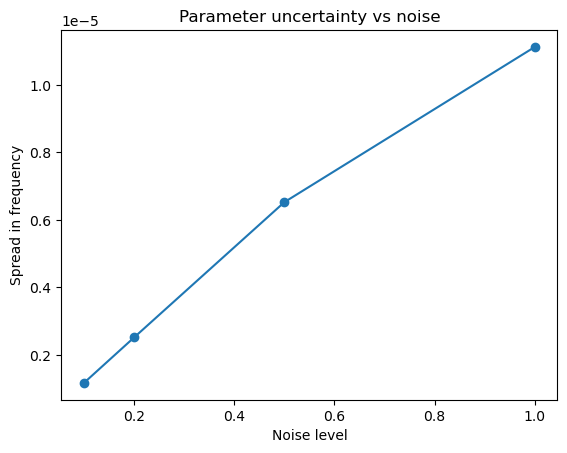

In [162]:
noise_levels = [0.1, 0.2, 0.5, 1.0]
chi2_mean = []
nu_std = []
for sigma in noise_levels:
    chi2_vals = []
    nu_vals = []
    for i in range(50):
        noisy_data = true_data + np.random.normal(0, sigma, size=t.size)
        res = minimize(
            chisq,
            x0=init_guess,
            args=(noisy_data, t),
            jac=grad_chisq,
            method="BFGS"
        )
        A_fit, nu_fit = res.x
        nu_vals.append(nu_fit)
        fit_model = m(A_fit, nu_fit, t)
        chi2 = np.sum((noisy_data - fit_model) ** 2 / sigma**2)
        chi2_vals.append(chi2 / (len(t) - 2))
    chi2_mean.append(np.mean(chi2_vals))
    nu_std.append(np.std(nu_vals))

plt.plot(noise_levels, chi2_mean, marker='o')
plt.xlabel("Noise level")
plt.ylabel("Reduced χ²")
plt.title("Fit quality vs noise (sine)")
plt.savefig("sine_chi2_vs_noise.pdf")
plt.show()

plt.plot(noise_levels, nu_std, marker='o')
plt.xlabel("Noise level")
plt.ylabel("Spread in frequency")
plt.title("Parameter uncertainty vs noise")
plt.savefig("sine_nu_uncertainty.pdf")
plt.show()

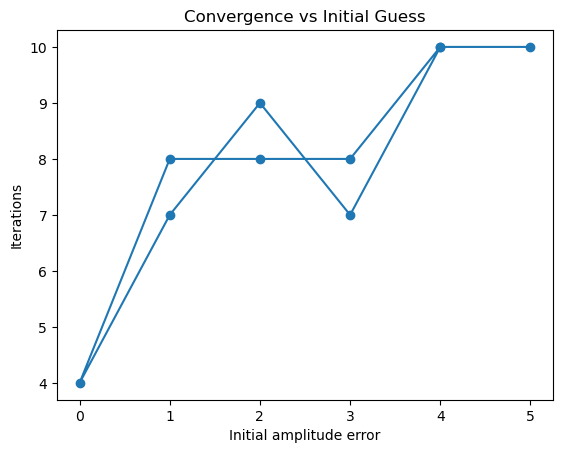

In [163]:
A_guesses = np.linspace(1, 10, 10)
nit_vals = []
error_vals = []
for A_guess in A_guesses:
    init_guess = np.array([A_guess, 0.05])
    res = minimize(
        chisq,
        x0=init_guess,
        args=(noisy_data, t),
        jac=grad_chisq,
        method="BFGS"
    )
    nit_vals.append(res.nit)
    error_vals.append(abs(A_guess - A0))

plt.plot(error_vals, nit_vals, marker='o')
plt.xlabel("Initial amplitude error")
plt.ylabel("Iterations")
plt.title("Convergence vs Initial Guess")
plt.savefig("sine_iterations_vs_init.pdf")
plt.show()

Does the best-fit provide a good description of the noisy data? If not, then something probably went wrong, and you should try debugging your code to fix it.

# Maximum Likelihood

We can make these optimization problems a bit more well-rooted by framing them as a statistics problem:  
  
**How likely is it that the model describes the data I have?**  
  
In this case, if we think we understand the statistics of our data, then we can define a *likelihood* $\mathcal{L}$ and fidget with the model parameters until we have maximized the likelihood that the model describes the data we have been given. In a Bayesian scheme, usually the likelihood is written down as  
  
$$
    \mathcal{L}(\theta | d),
$$  
  
which you can think of as quantifying "how likely is this set of model parameters $\theta$ given some (fixed) data $d$". (This is not the same as "how probable", but it can be used as a measure of how well the data is described by the model.)  
  
Usually, we assume that the random fluctuations in our data are Gaussian, and this means that the likelihood is a joint Gaussian distribution:  
  
$$
    \mathcal{L}(\theta | d) = \prod_i (2\pi\sigma_i^2)^{-1/2} \exp \Biggl( -\frac{[d_i - m_i(\theta)]^2}{2\sigma_i^2}\Biggr).
$$  
  
If we have $N$ data points with equal variance, then this can be rewritten as  
  
$$
    \mathcal{L}(\theta | d) = (2\pi \sigma^2)^{-N/2} \exp\biggl(-\frac{1}{2}\chi^2\biggr).
$$  
  
In this case, maximizing the likelihood is equivalent to minimizing $\chi^2$, so we can employ the same tricks from the previous sections. This is a bit of a nicer extension though, since in a Bayesian framework we can also apply constraints based on *priors*, or rather leverage information about what values we think the model parameters ought to be able to take on (either from other experiments or from physical arguments).  
  
I'm not going to say much more about this, because frankly I don't really think I'm qualified to say much more. Here are a few things I would like you to keep in mind, though:  
* Maximizing the likelihood is equivalent to minimizing the negative log-likelihood. We have plenty of helpful tools available for minimizing things, and log-likelihoods are typically much better behaved numerically than likelihoods (exponentials are sensitive to small changes, and this can make numerical things involving exponentials difficult to work with).
* CorrCal is formally framed as a maximum likelihood routine where the data is treated as *correlated* noise, and rather than model the data directly, we model the *covariance* in the data. This is a very non-traditional approach, but it's talked about in a bit more detail in the CorrCal tutorial notebook and paper.